In [129]:
import torch
import torch.nn as nn
import pickle
import numpy as np
import torchvision
from torchvision.models import vgg11, ResNet50_Weights, resnet50
import matplotlib.pyplot as plt
from torch.utils.flop_counter import FlopCounterMode
from typing import Union, Tuple
import os
from mpl_toolkits import axes_grid1
import re

In [185]:
def is_cnn_layer(module):
    # Check if the module has no children
    has_no_children = len(list(module.children())) == 0

    # Only use convolutional layers to determine when to freeze
    is_target_type = isinstance(module, (nn.Conv2d))

    return has_no_children and is_target_type

In [186]:
dataset = "cifar100"
model_name = "resnet50"
num_epochs = 160
name_of_experiment = "mambafrz_20_conv_seed_25_experiment"
name_of_location_for_training_data = "mambafrz_20_conv_seed_25_experiment/longer_context_training_plus_testing_dataset"
device = "cuda:0"
number_of_cnn_layers = 20

In [187]:
layer_names = []
all_cnn_layer_names = []
model = resnet50(weights=None)
counter_for_cnn_layers = number_of_cnn_layers
sampled_indices = np.linspace(0, 52, counter_for_cnn_layers).astype(int)
current_index_for_indices = 0
index_counter_for_cnn_layers = 0
  
for name, module in model.named_modules():
    if counter_for_cnn_layers == 0:
        break
    if is_cnn_layer(module):
        all_cnn_layer_names.append(name)
        if index_counter_for_cnn_layers == sampled_indices[current_index_for_indices]:
            layer_names.append(name)
            counter_for_cnn_layers -= 1
            current_index_for_indices += 1
        
        # Always increment index counter
        index_counter_for_cnn_layers += 1
print(f"Length of all CNN layer names: {len(all_cnn_layer_names)}")
print(f"Length of evenly sampled CNN layer names: {len(layer_names)}")

Length of all CNN layer names: 53
Length of evenly sampled CNN layer names: 20


In [188]:
layer_names

['conv1',
 'layer1.0.conv2',
 'layer1.1.conv1',
 'layer1.2.conv1',
 'layer1.2.conv3',
 'layer2.0.conv3',
 'layer2.1.conv2',
 'layer2.2.conv2',
 'layer2.3.conv1',
 'layer3.0.conv1',
 'layer3.0.downsample.0',
 'layer3.1.conv3',
 'layer3.2.conv2',
 'layer3.3.conv2',
 'layer3.4.conv2',
 'layer3.5.conv2',
 'layer4.0.conv1',
 'layer4.0.downsample.0',
 'layer4.1.conv3',
 'layer4.2.conv3']

In [205]:
# Get a list of all the seeds from which data was generated
seed_directories = [folder_name for folder_name in os.listdir(name_of_experiment) if "seed" in folder_name[:5]]

In [206]:
print(f"Number of seeds generated: {len(seed_directories)}")

Number of seeds generated: 25


In [207]:
seed_directories = seed_directories[-2:] # Take last 2 seeds as the testing dataset, eventually will generate both
testing_seed_directories = seed_directories[:22] # Take first 22 seeds for the training dataset

## (1) Look At CKA Plots from Different Seeds

In [208]:
# First look at CKA values across epochs heatmap
def add_colorbar(im, aspect=10, pad_fraction=0.5, **kwargs):
    """Add a vertical color bar to an image plot."""
    divider = axes_grid1.make_axes_locatable(im.axes)
    width = axes_grid1.axes_size.AxesY(im.axes, aspect=1./aspect)
    pad = axes_grid1.axes_size.Fraction(pad_fraction, width)
    current_ax = plt.gca()
    cax = divider.append_axes("right", size=width, pad=pad)
    plt.sca(current_ax)
    return im.axes.figure.colorbar(im, cax=cax, **kwargs)

def plot_results(
          cka_mini_batch_vector,
          save_path: str = None,
          title: str = None
          ):
        fig, ax = plt.subplots()

        reshaped_cka_mini_batch_vector = cka_mini_batch_vector.T
        im = ax.imshow(reshaped_cka_mini_batch_vector, origin='lower', cmap='magma', vmin=0.0, vmax=1.0)

        if title is not None:
            ax.set_title(f"{title}", fontsize=18)
        else:
            ax.set_title("Similarity to Fully Trained Model over Time", fontsize=18)

        # Set axis labels
        ax.set_ylabel("CNN Layer Index", fontsize=14)
        ax.set_xlabel("Epochs", fontsize=14)

        add_colorbar(im, ticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

        if save_path is not None:
            plt.savefig(save_path, dpi=1000)

        plt.show()

In [209]:
def plot_cka_over_time(cka_over_time_file, seed):
    with open(cka_over_time_file, 'rb') as f:
        cka_over_time = pickle.load(f)
    # print(cka_over_time)
    list_of_layers = list(cka_over_time.keys())
    print(f"List of Layers: {list_of_layers}")
    max_epochs = max(len(cka_over_time[key]) for key in list(cka_over_time.keys()))
    max_layers = len(list_of_layers)
    cka_matrix = torch.zeros((max_layers, max_epochs))
    for layer_index, layer in enumerate(list_of_layers):
        max_epochs_trained_for_layer = len(cka_over_time[layer])
        for epoch in range(max_epochs_trained_for_layer):
            cka_matrix[layer_index][epoch] = cka_over_time[layer][epoch]
    cka_matrix = cka_matrix.T
    plot_results(cka_matrix, title=f"Seed {seed}")

1975
List of Layers: ['conv1', 'layer1.0.conv2', 'layer1.1.conv1', 'layer1.2.conv1', 'layer1.2.conv3', 'layer2.0.conv3', 'layer2.1.conv2', 'layer2.2.conv2', 'layer2.3.conv1', 'layer3.0.conv1', 'layer3.0.downsample.0', 'layer3.1.conv3', 'layer3.2.conv2', 'layer3.3.conv2', 'layer3.4.conv2', 'layer3.5.conv2', 'layer4.0.conv1', 'layer4.0.downsample.0', 'layer4.1.conv3', 'layer4.2.conv3']


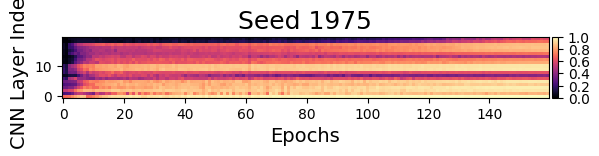

1552
List of Layers: ['conv1', 'layer1.0.conv2', 'layer1.1.conv1', 'layer1.2.conv1', 'layer1.2.conv3', 'layer2.0.conv3', 'layer2.1.conv2', 'layer2.2.conv2', 'layer2.3.conv1', 'layer3.0.conv1', 'layer3.0.downsample.0', 'layer3.1.conv3', 'layer3.2.conv2', 'layer3.3.conv2', 'layer3.4.conv2', 'layer3.5.conv2', 'layer4.0.conv1', 'layer4.0.downsample.0', 'layer4.1.conv3', 'layer4.2.conv3']


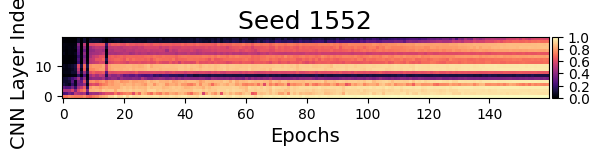

In [210]:
for seed_directory in seed_directories:
    path_to_cka = os.path.join(name_of_experiment, seed_directory, "resnet50_cka_values_across_epochs.pkl")
    match = re.search(r"(\d+)$", seed_directory)
    if match:
        seed = int(match.group(1))
        print(seed)
    plot_cka_over_time(path_to_cka, seed)

## (2) Compare the metrics of two different seeds, arbitrarily choose

In [211]:
def plot_accuracy_of_full_vs_similarity_guided_training_metrics(full_training_file, similarity_guided_training_file):
    with open(full_training_file, 'rb') as f:
        full_training = pickle.load(f)
    with open(similarity_guided_training_file, 'rb') as f:
        similarity_guided_training = pickle.load(f)

    acc_full, train_loss_full, test_loss_full = full_training
    acc_sim, train_loss_sim, test_loss_sim = similarity_guided_training

    epochs = list(range(1, len(acc_full) + 1))

    for index, (acc1, acc2) in enumerate(zip(acc_full, acc_sim)):
        acc_full[index] = acc1 * 100.0
        acc_sim[index] = acc2 * 100.0
    print(f"Max Accuracy Full Training: {max(acc_full)}")
    print(f"Max Accuracy Similarity-Guided Training: {max(acc_sim)}")
    # Plot Accuracy
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, acc_full, label='End-to-End Accuracy')
    plt.plot(epochs, acc_sim, label='Similarity-Guided Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot Training Loss
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, train_loss_full, label='End-to-End Training Loss')
    plt.plot(epochs, train_loss_sim, label='Similarity-Guided Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Training Loss')
    plt.title('Training Loss over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot Validation Loss
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, train_loss_full, label='End-to-End Validation Loss')
    plt.plot(epochs, train_loss_sim, label='Similarity-Guided Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Loss')
    plt.title('Validation Loss over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

Max Accuracy Full Training: 82.67
Max Accuracy Similarity-Guided Training: 82.67


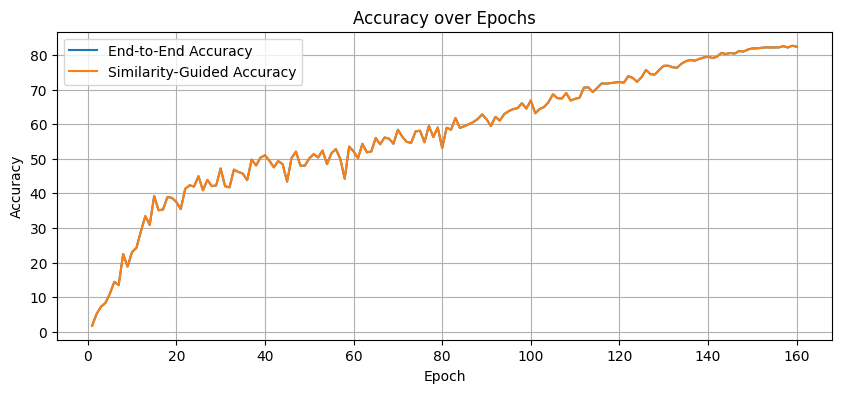

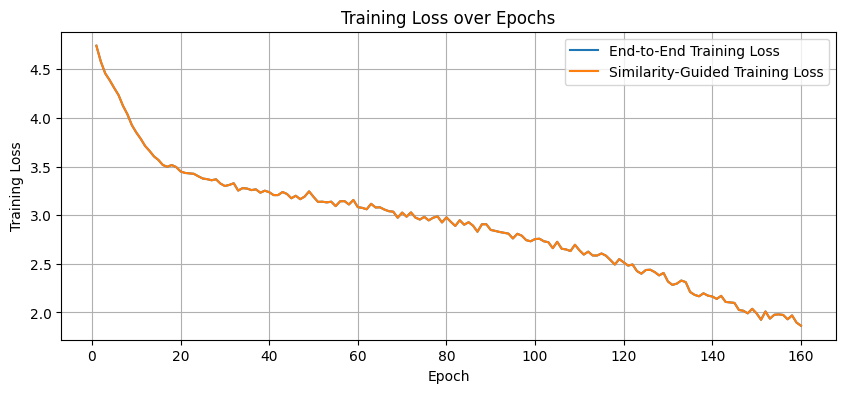

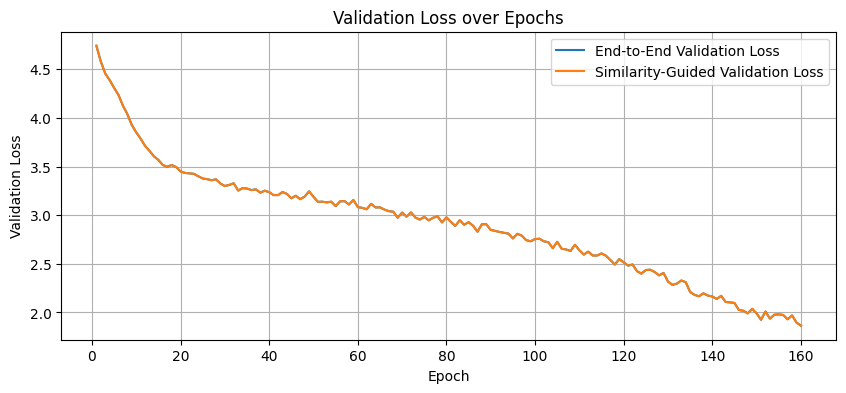

In [212]:
seed_test_1 = 9614
seed_test_2 = 9614
plot_accuracy_of_full_vs_similarity_guided_training_metrics(os.path.join(name_of_experiment, f"seed_{seed_test_1}", "fully_trained_reference_model_resnet50_metrics.pkl"), os.path.join(name_of_experiment, f"seed_{seed_test_2}", "fully_trained_reference_model_resnet50_metrics.pkl"))

## (3) Plot CKA Curves to Compare

In [213]:
def plot_cka_over_time_results(all_epochs_matrix, number_of_conv, seed):
    # Convert PyTorch tensor to NumPy if needed
    if isinstance(all_epochs_matrix, torch.Tensor):
        all_epochs_matrix = all_epochs_matrix.cpu().numpy()

    num_rows, num_cols = all_epochs_matrix.shape
    time_steps = np.arange(num_rows)

    for i in range(number_of_conv):
        plt.title(f"Conv # {i}, Seed {seed}")
        plt.plot(time_steps, all_epochs_matrix[:, i])
    plt.show()

def compare_plots_of_cka_over_time(all_epochs_matrix_one, all_epochs_matrix_two, number_of_conv, seed_one, seed_two):
    if isinstance(all_epochs_matrix_one, torch.Tensor):
        all_epochs_matrix_one = all_epochs_matrix_one.cpu().numpy()
        all_epochs_matrix_two = all_epochs_matrix_two.cpu().numpy()
    
    num_rows, num_cols = all_epochs_matrix_one.shape
    time_steps = np.arange(num_rows)
    for i in range(number_of_conv):
        plt.title(f"Conv # {i}, Seed {seed_one} vs. Seed {seed_two}")
        plt.plot(time_steps, all_epochs_matrix_one[:, i])
        plt.plot(time_steps, all_epochs_matrix_two[:, i])
    plt.show()
    
def process_cka_over_time_file_for_plot(seed_directory):
    global name_of_experiment
    cka_over_time_file = os.path.join(name_of_experiment, seed_directory, "resnet50_cka_values_across_epochs.pkl")
    with open(cka_over_time_file, "rb") as f:
        cka_over_time = pickle.load(f)
    list_of_layers = list(cka_over_time.keys())
    max_epochs = max(len(cka_over_time[key]) for key in list(cka_over_time.keys()))
    max_layers = len(list_of_layers)
    cka_matrix = torch.zeros((max_layers, max_epochs))
    for layer_index, layer in enumerate(list_of_layers):
        max_epochs_trained_for_layer = len(cka_over_time[layer])
        for epoch in range(max_epochs_trained_for_layer):
            cka_matrix[layer_index][epoch] = cka_over_time[layer][epoch]
    all_epochs_matrix = cka_matrix.T
    return all_epochs_matrix

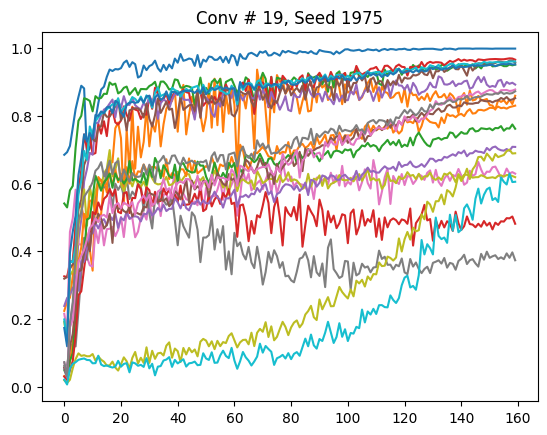

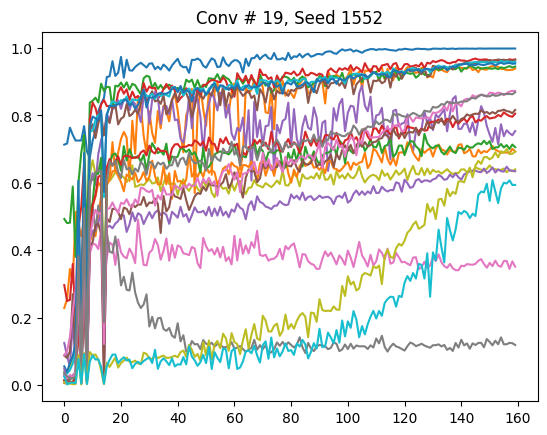

In [214]:
for seed_directory in seed_directories:
    all_epochs_matrix = process_cka_over_time_file_for_plot(seed_directory)
    match = re.search(r"(\d+)$", seed_directory)
    if match:
        seed = int(match.group(1))
    plot_cka_over_time_results(all_epochs_matrix, number_of_cnn_layers, seed)

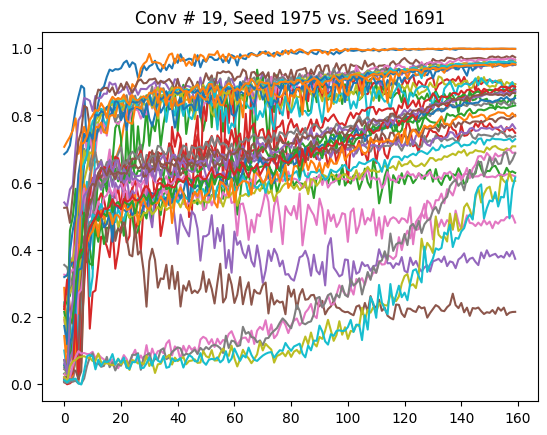

In [215]:
# Compare CKA of different seeds
seed_one_test = 1975
seed_two_test = 1691
all_epochs_matrix_one = process_cka_over_time_file_for_plot(f"seed_{seed_one_test}")
all_epochs_matrix_two = process_cka_over_time_file_for_plot(f"seed_{seed_two_test}")
compare_plots_of_cka_over_time(all_epochs_matrix_one, all_epochs_matrix_two, number_of_cnn_layers, seed_one_test, seed_two_test)

## (4) Generate Labels Based on Variance of CKA Values

In [216]:
def get_all_stability_points_for_all_layers(
    all_epochs_matrix, conv_indices, layers, seed, moving_window=20, stride=5, stability_threshold=0.0002, cka_change_rate_threshold_between_strides=0.02
):
    cka_freeze_configuration = {layer: [] for layer in layers}
    num_epochs = all_epochs_matrix.shape[0]

    for conv_idx in conv_indices:
        cka_vals = all_epochs_matrix[:, conv_idx]
        if hasattr(cka_vals, 'cpu'):
            cka_vals = cka_vals.cpu().numpy()

        cka_window_values = []
        variance_values = []   # Store variance for plotting
        variance_epochs = []   # Track the center of the window for plotting

        prev_decision_was_frozen = False
        prev_CKA_at_decision_for_frozen = None

        for epoch, cka_val in enumerate(cka_vals):
            cka_window_values.append(cka_val)

            if len(cka_window_values) > moving_window:
                cka_window_values = cka_window_values[stride:]

            if len(cka_window_values) == moving_window:
                window_variance = np.var(cka_window_values, ddof=1)

                center_epoch = (epoch - moving_window + 1) // 2
                start_of_epoch = epoch - moving_window + 1
                # print(f"The Current Epoch: {epoch}, Start of Epoch: {epoch} - {moving_window} = {start_of_epoch}")
                variance_values.append(window_variance)
                variance_epochs.append(center_epoch)
                # After the initial freeze decision, make it so that all labels subsequently are of a frozen layer
                # Doesn't make sense to go back and forth with freezing, measure performance difference after. Weights should change slightly anyway
                if window_variance < stability_threshold and cka_val > 0.3 or cka_freeze_configuration[layers[conv_idx]][-1] == 1:
                    # print(f"Layer {conv_idx} — CKA value when freezing: ", cka_val)
                    # print("Variance of window: ", window_variance)
                    cka_freeze_configuration[layers[conv_idx]].append(1) # 1 for frozen layer
                    cka_freeze_configuration[layers[conv_idx]][-(moving_window//2):] = [1] * (moving_window//2) # replace last moving_window//2 elements with 1 for frz
                    prev_decision_was_frozen = True
                    prev_CKA_at_decision_for_frozen = cka_val
                else:
                  cka_freeze_configuration[layers[conv_idx]].append(0) # 0 for non-frozen layer
                  prev_decision_was_frozen = False
                  prev_CKA_at_decision_for_frozen = None
            else:
              if prev_decision_was_frozen:
                # Get percent change, has to be a less than 3% change from the CKA value that was previously frozen at
                prev_cka_value_pct_change = abs(prev_CKA_at_decision_for_frozen - cka_val) / prev_CKA_at_decision_for_frozen
                if prev_cka_value_pct_change < cka_change_rate_threshold_between_strides:
                  cka_freeze_configuration[layers[conv_idx]].append(1) # following previous decision of layer freezing
                else:
                  print(f"GREATER THAN {int(cka_change_rate_threshold_between_strides * 100.0)}% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER")
                  cka_freeze_configuration[layers[conv_idx]].append(0)
              else:
                cka_freeze_configuration[layers[conv_idx]].append(0) # following previous decision of layer freezing, or there haven't been enough epochs for test

        # Plotting
        fig, ax1 = plt.subplots(figsize=(12, 6))

        ax1.plot(cka_vals, label='Raw CKA', color='blue', alpha=0.3)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('CKA Similarity', color='blue')
        ax1.tick_params(axis='y', labelcolor='blue')
        ax1.set_ylim(0, 1.0)

        # Plot variance on secondary axis
        ax2 = ax1.twinx()
        ax2.plot(variance_epochs, variance_values, label='Variance', color='orange')
        ax2.set_ylabel('Window Variance', color='orange')
        ax2.set_ylim(0.0001, 0.001)
        ax2.tick_params(axis='y', labelcolor='orange')

        # Plot the first stability marker if found
        frz_moment = [epoch_index for epoch_index, frz_decision in enumerate(cka_freeze_configuration[layers[conv_idx]]) if frz_decision == 1]
        cka_val_at_frz_moment = [cka_vals[epoch_index] for epoch_index in frz_moment]
        if frz_moment is not None:
            ax1.plot(frz_moment, cka_val_at_frz_moment, 'ro', label=f'Stability Point (<{stability_threshold})')

        fig.suptitle(f'Seed {seed}, CKA and Variance — Conv {layers[conv_idx]}')
        fig.tight_layout()
        fig.legend(loc='upper right')
        plt.grid(True)
        plt.show()

    return cka_freeze_configuration

GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER


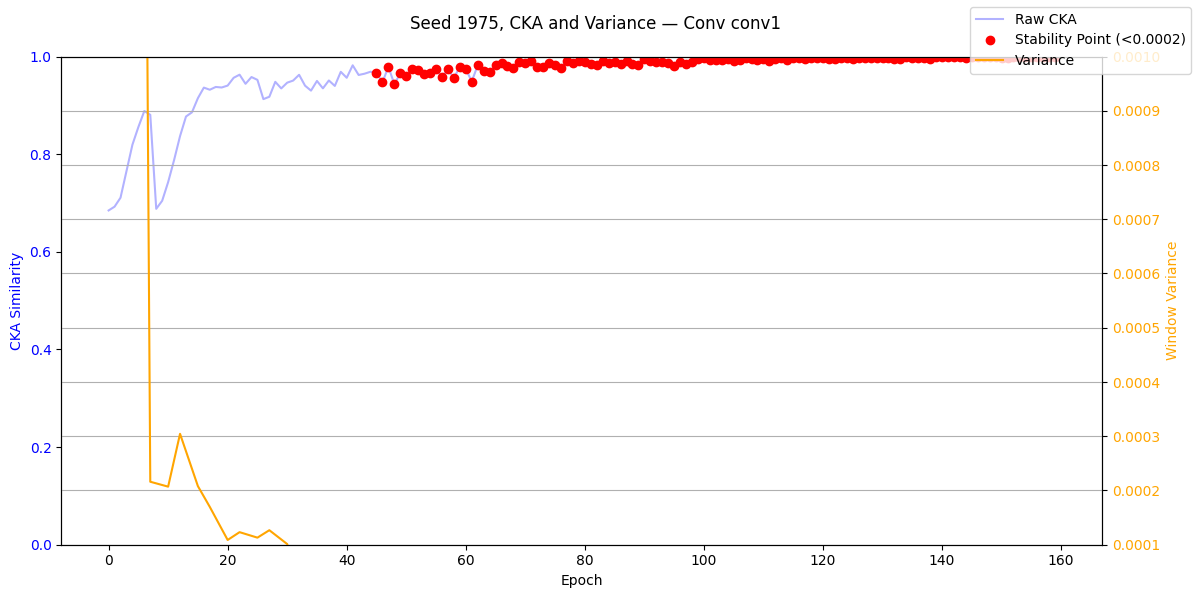

GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER


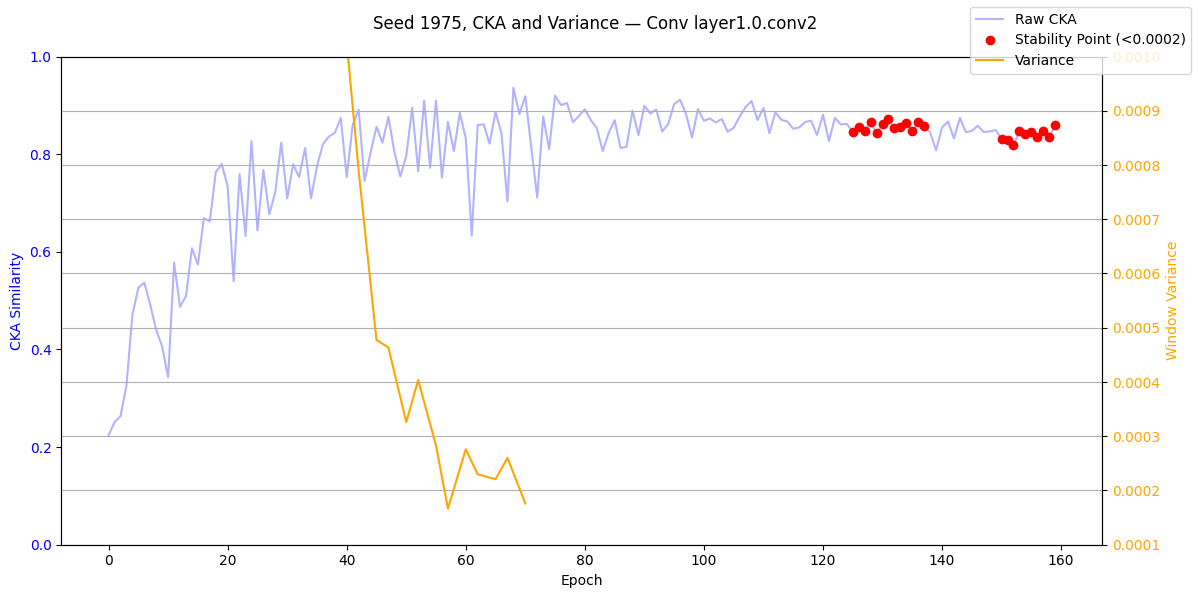

GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER


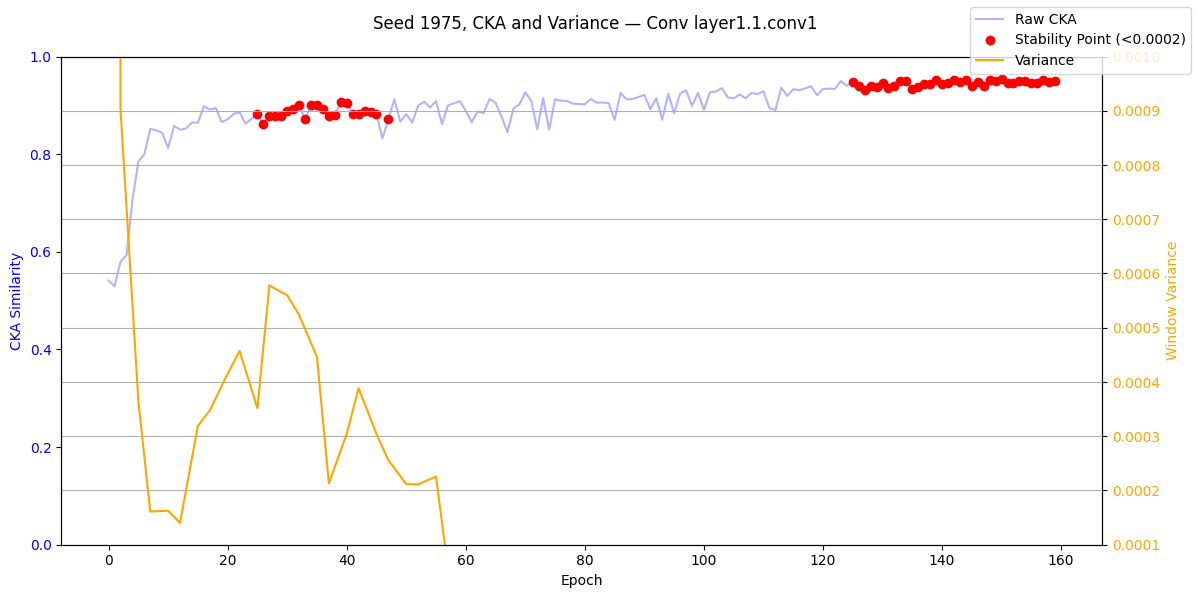

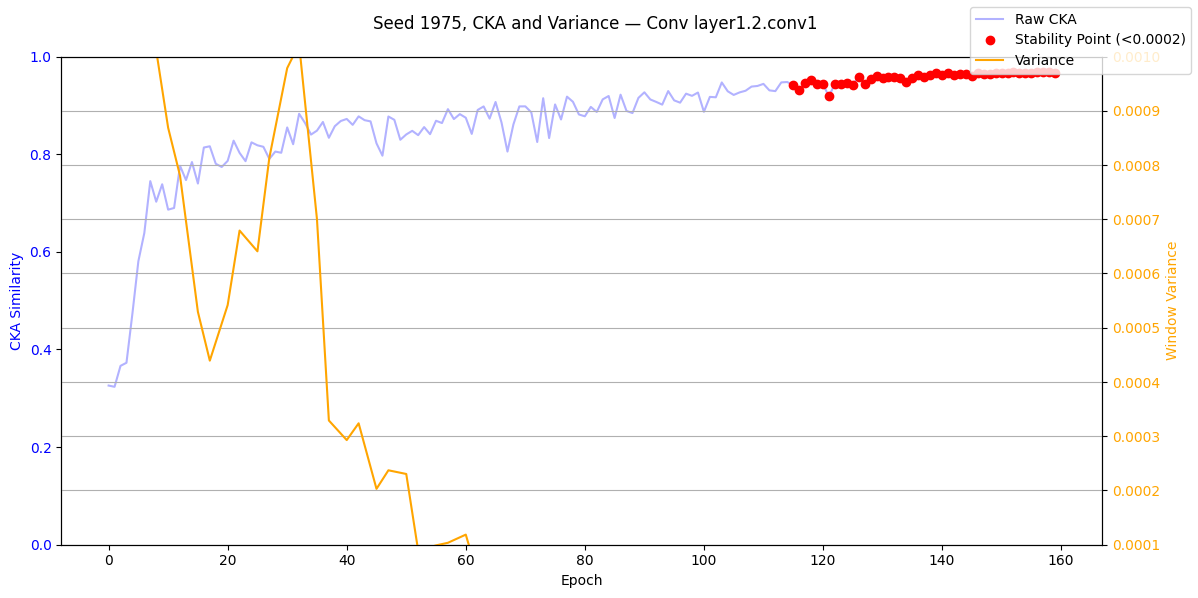

GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER


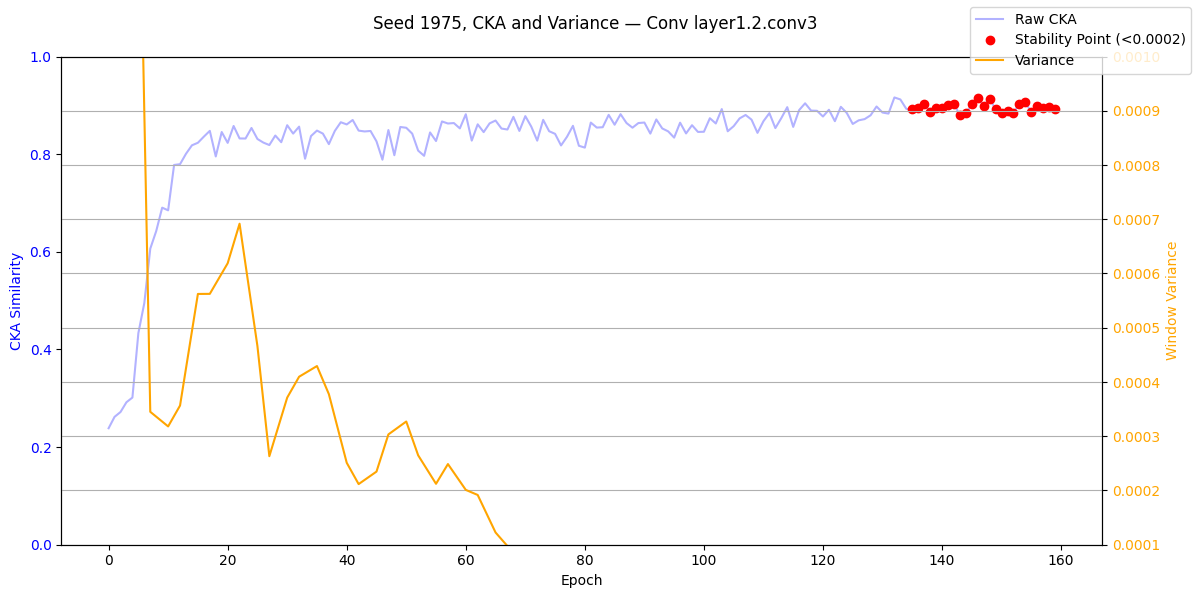

GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER


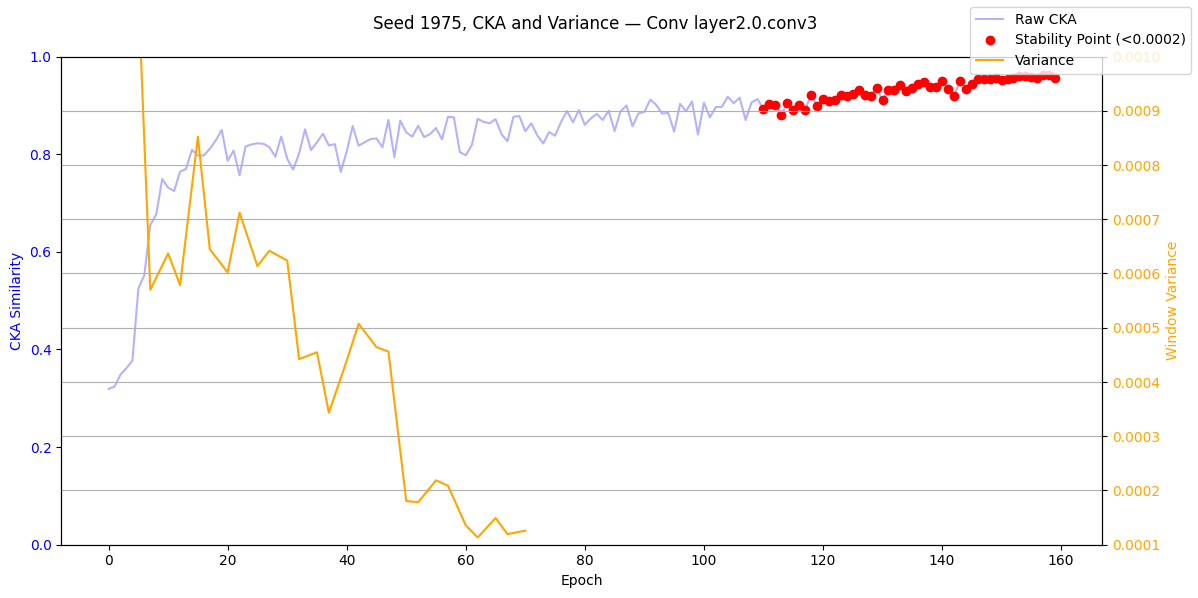

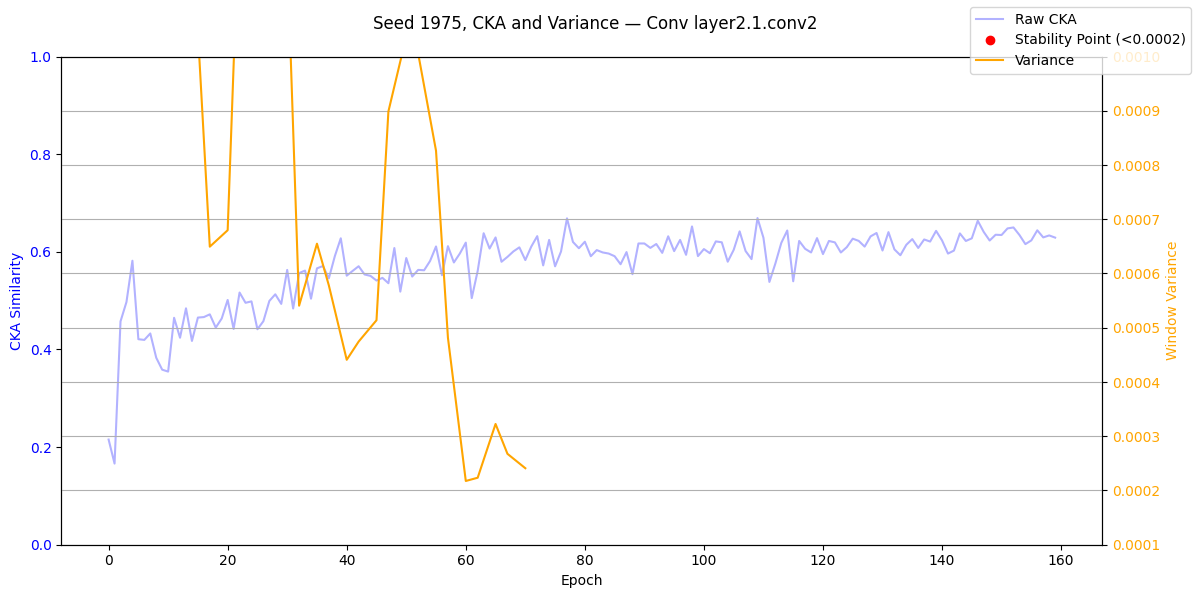

GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER


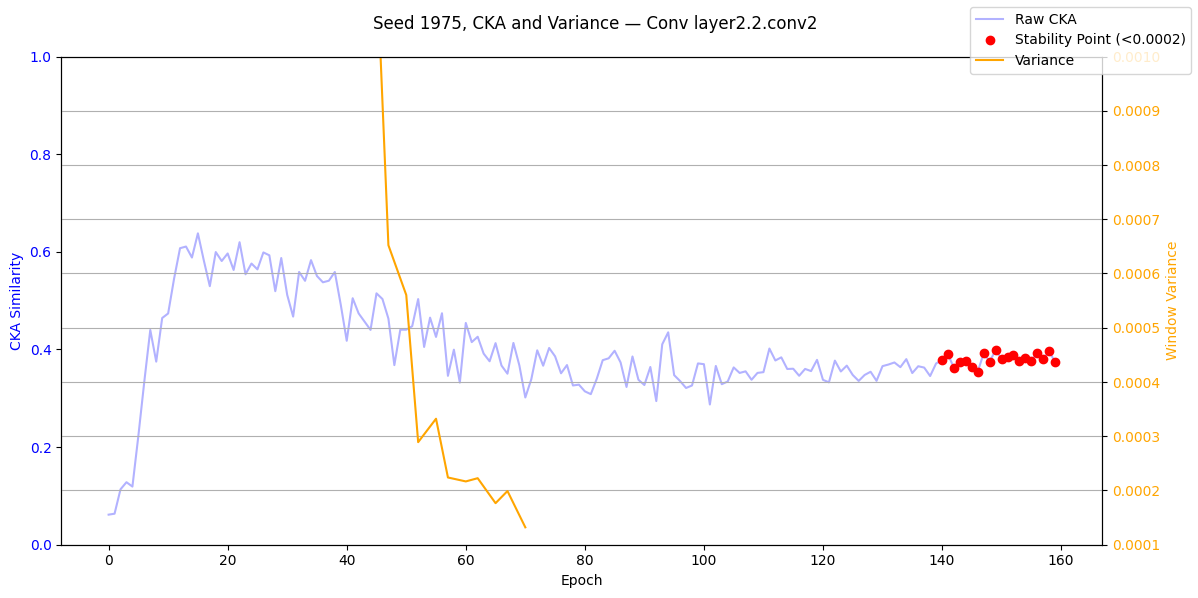

GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER TH

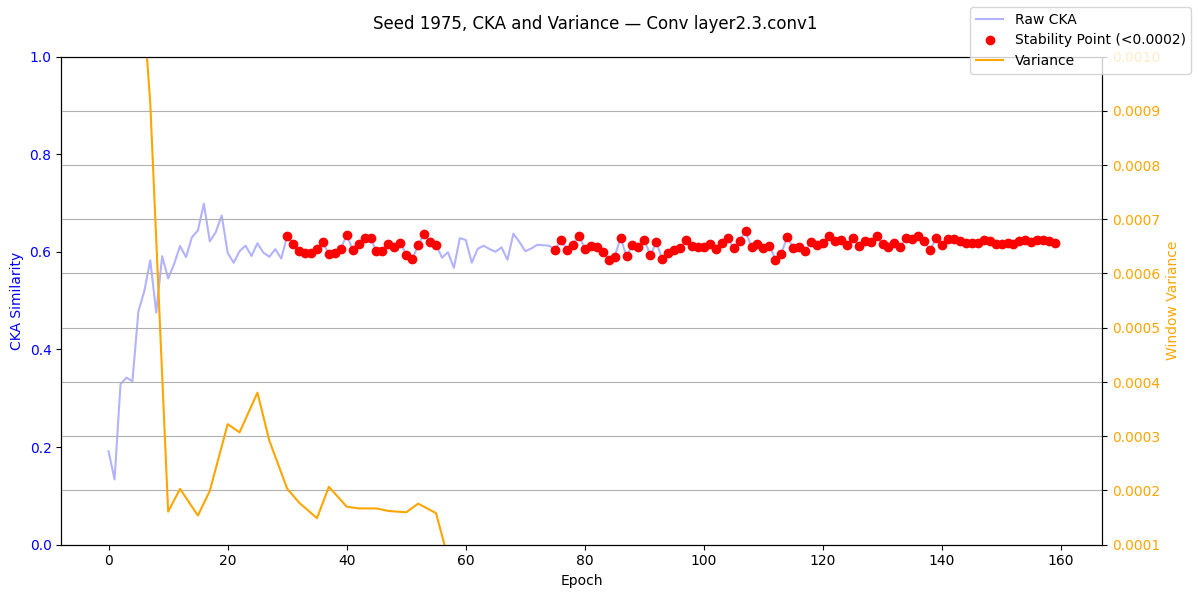

GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER


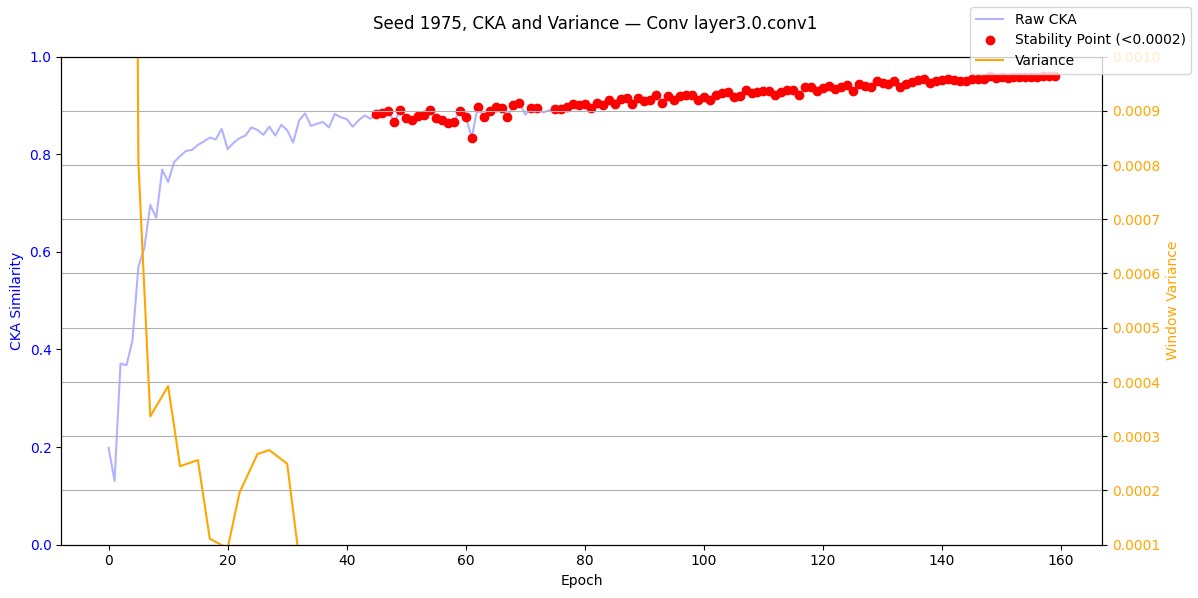

GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER


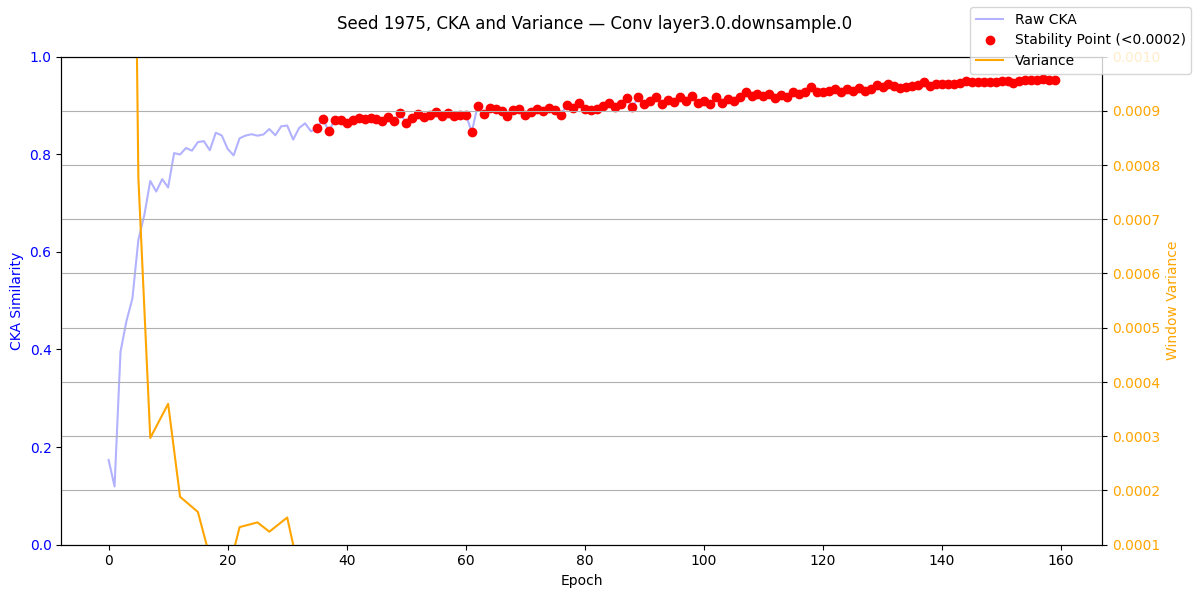

GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER


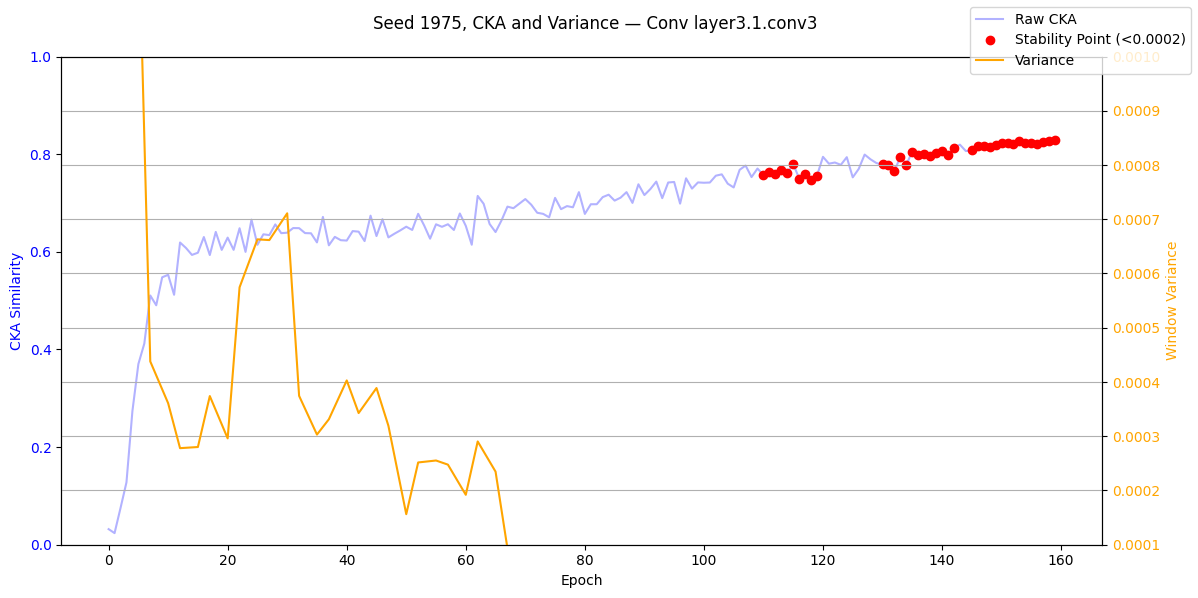

GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER TH

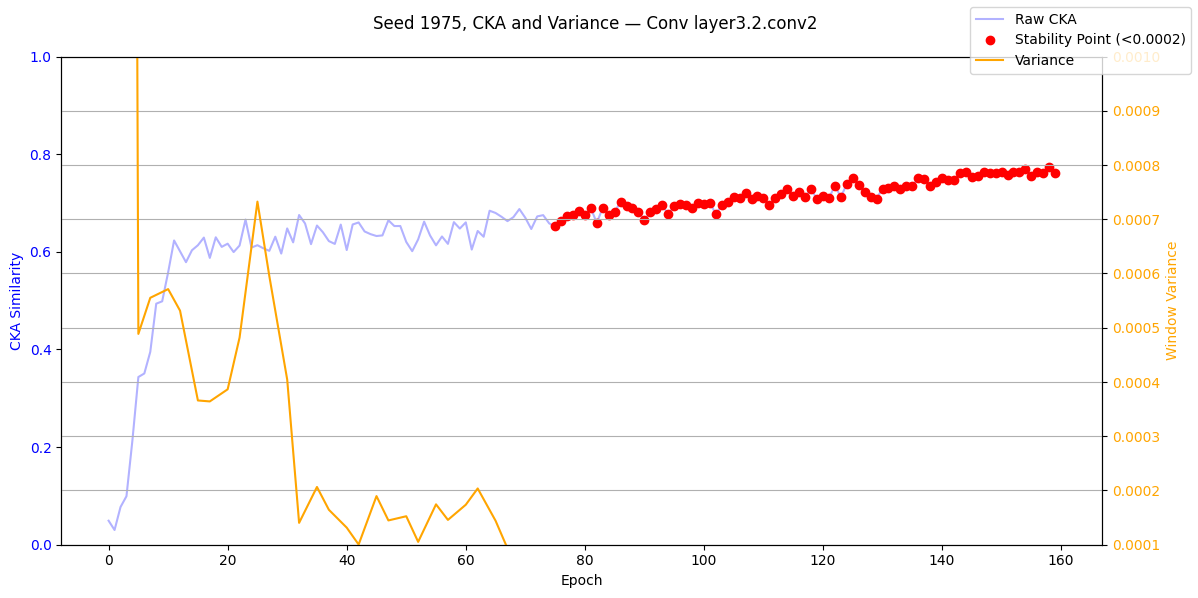

GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER


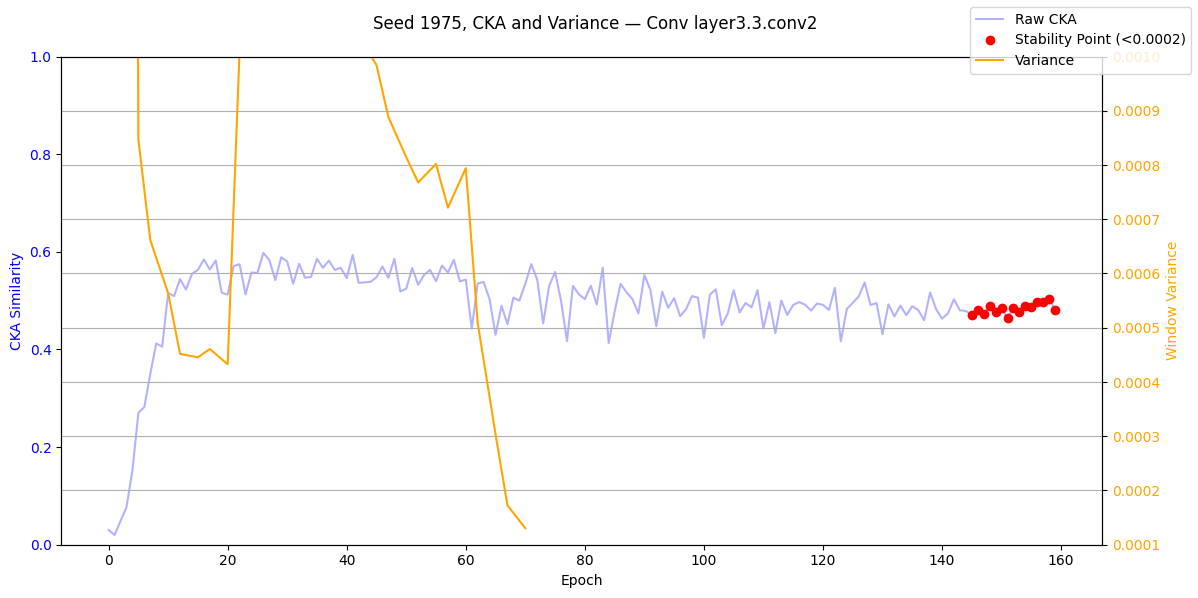

GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER


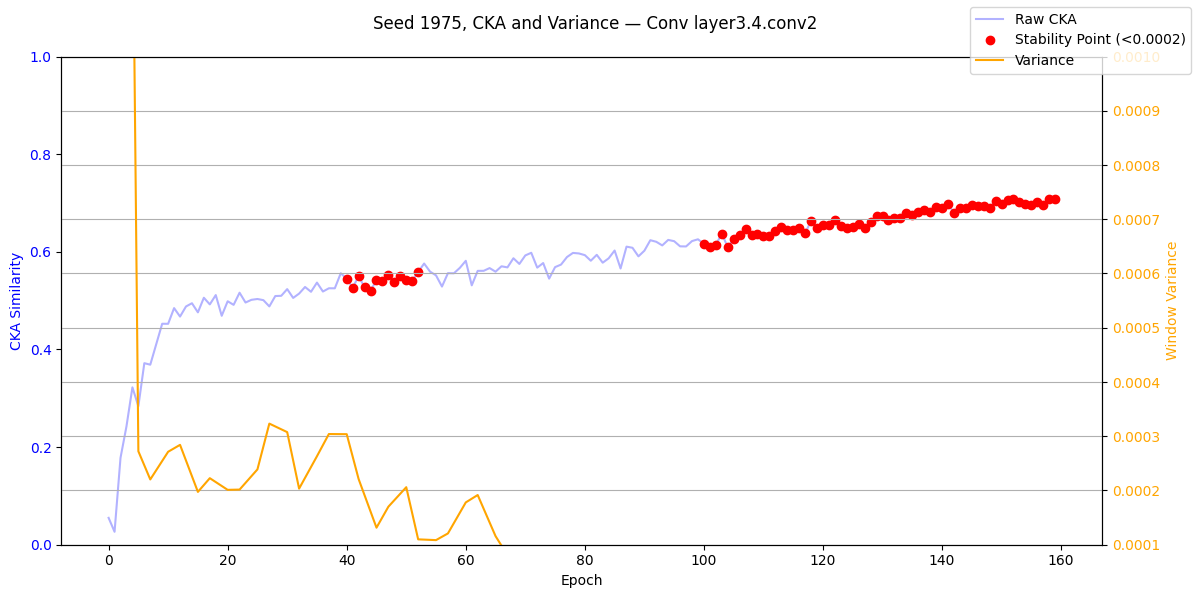

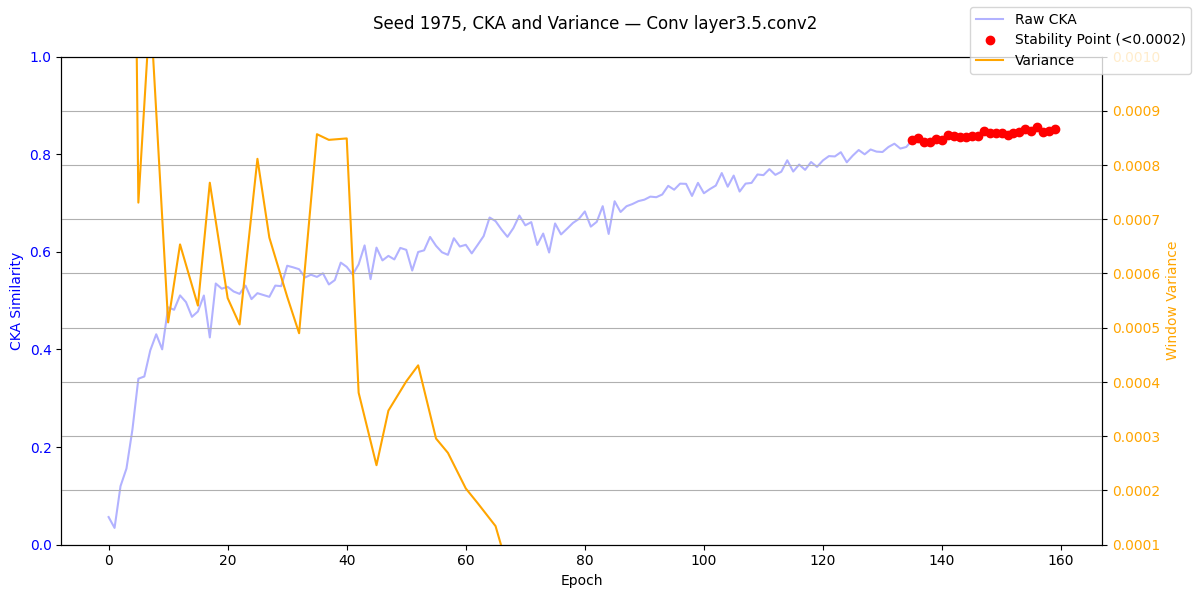

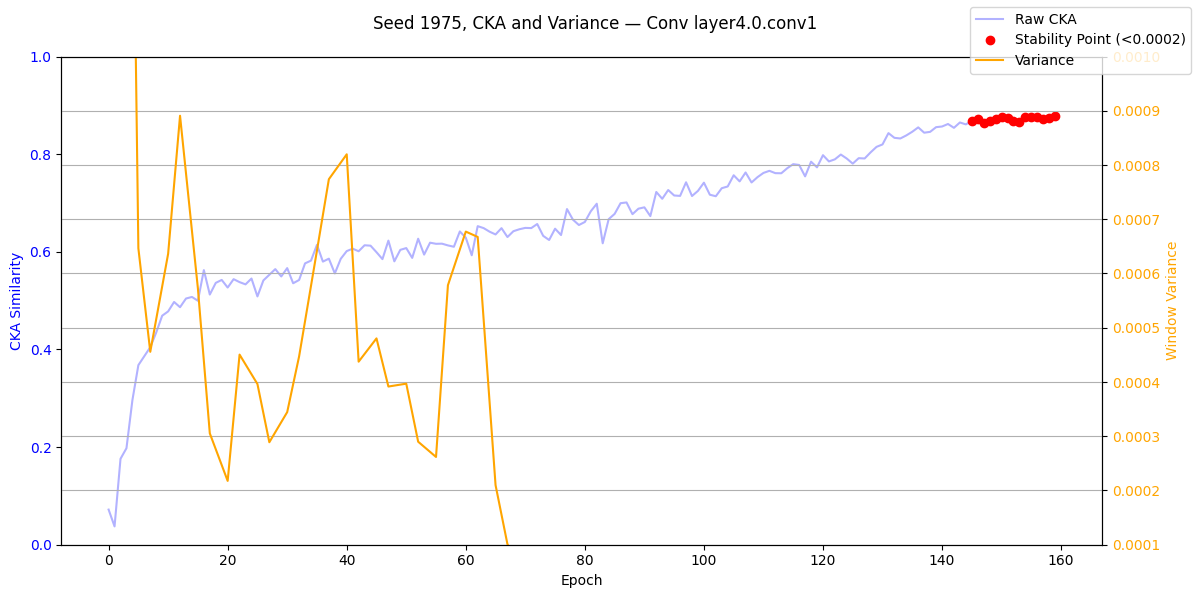

GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER


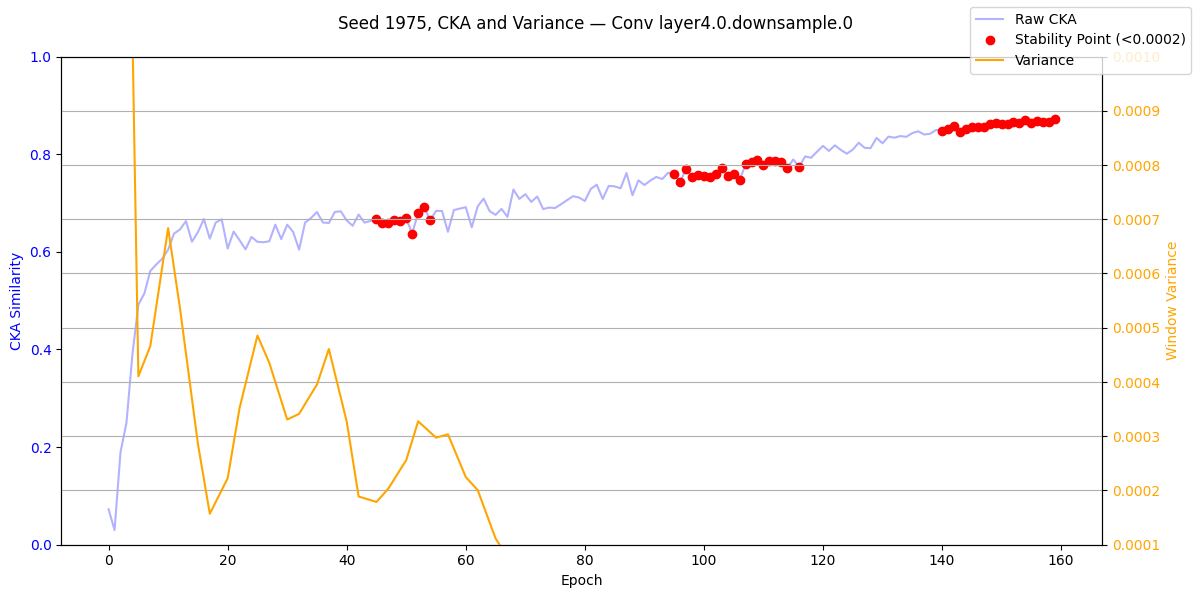

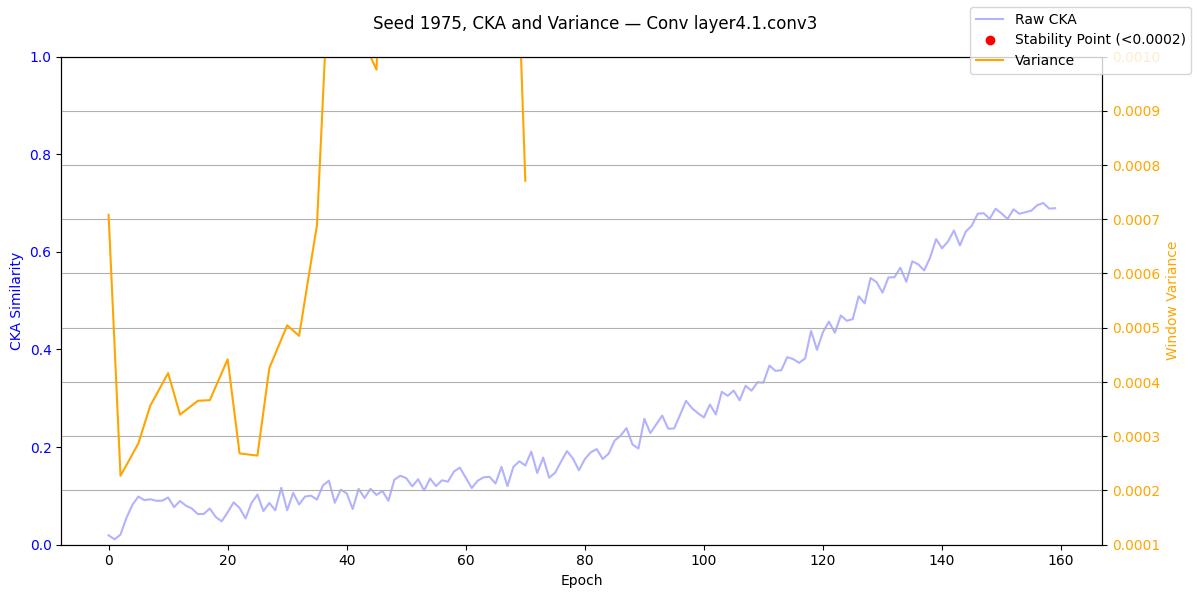

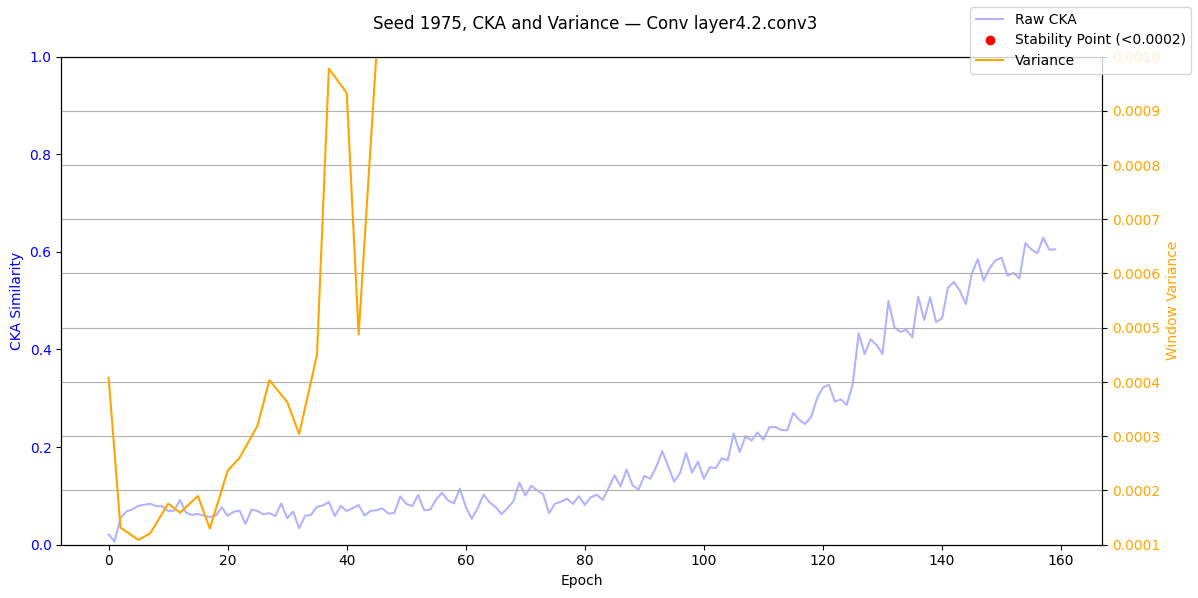

GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER


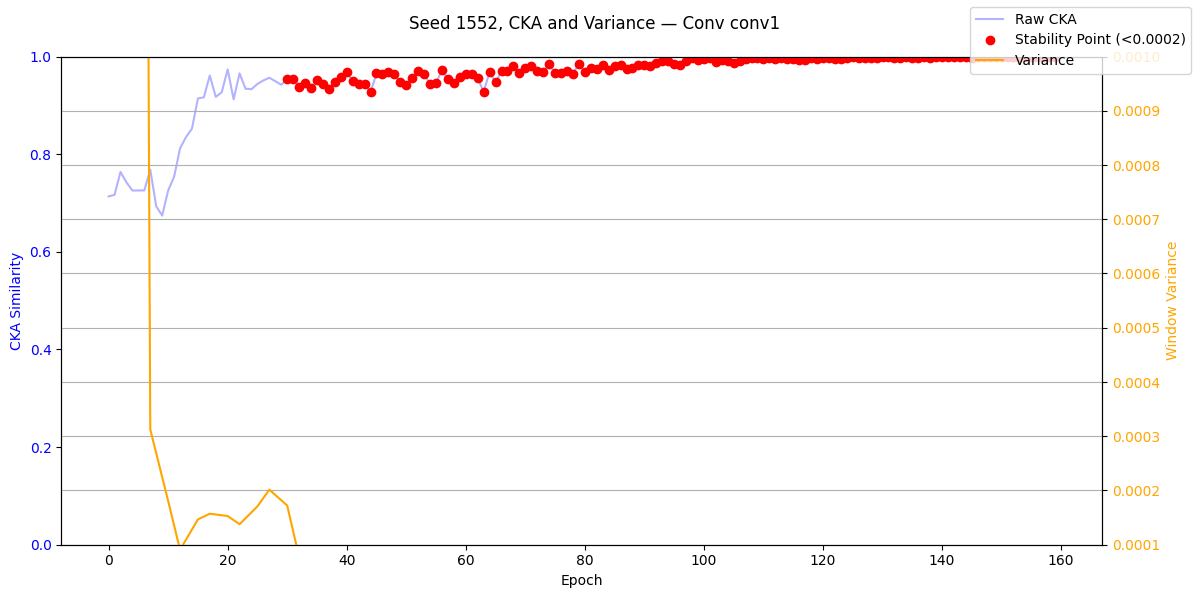

GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER


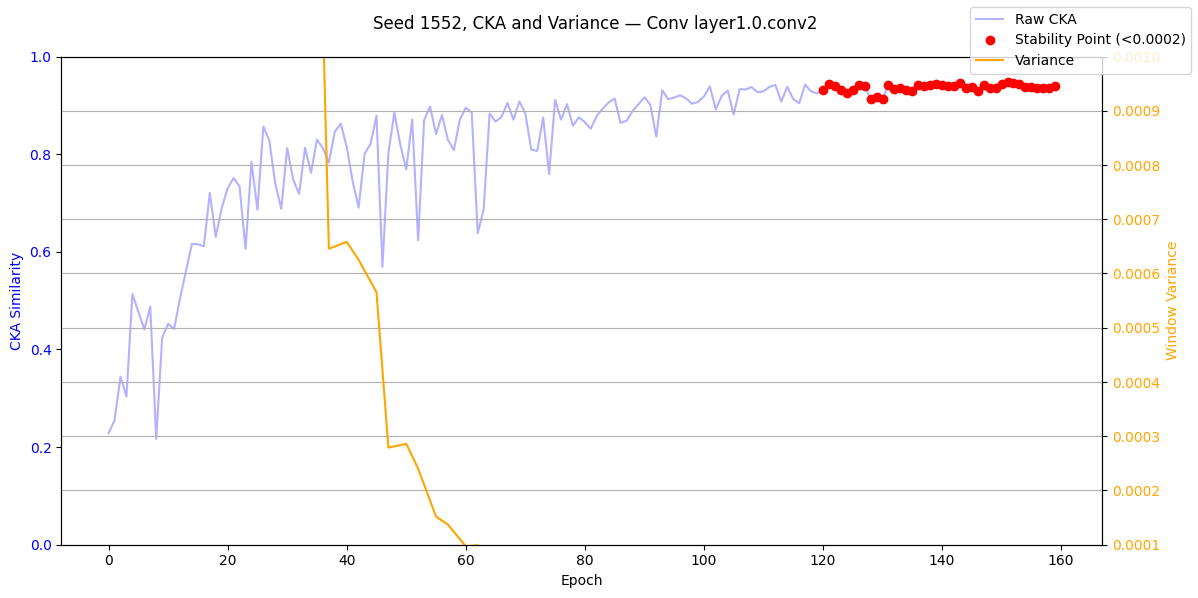

GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER


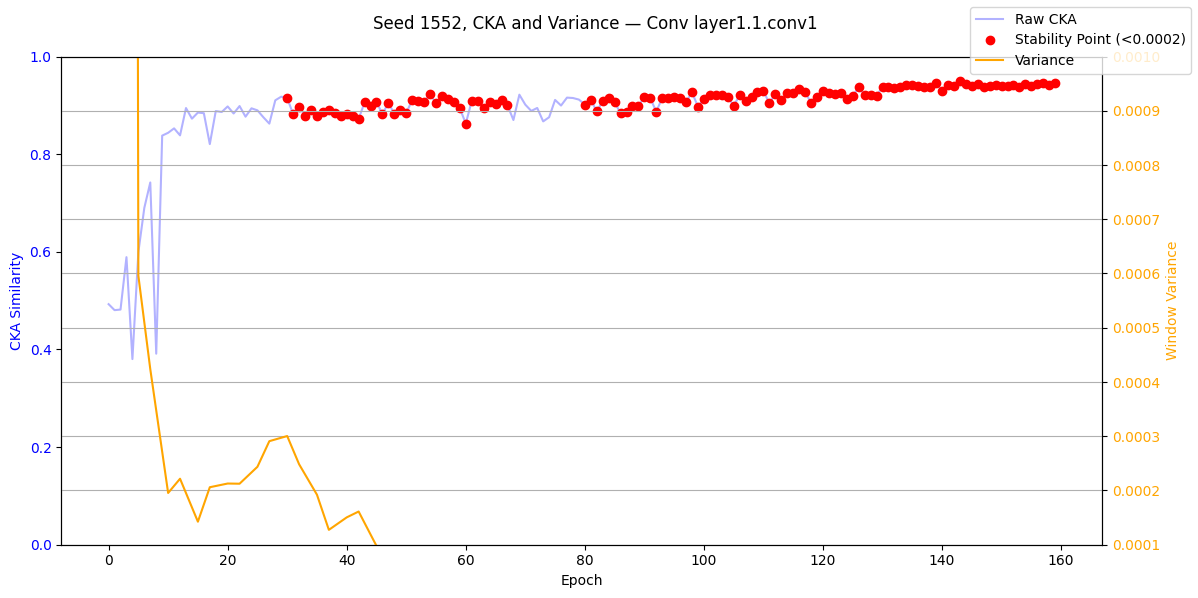

GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER


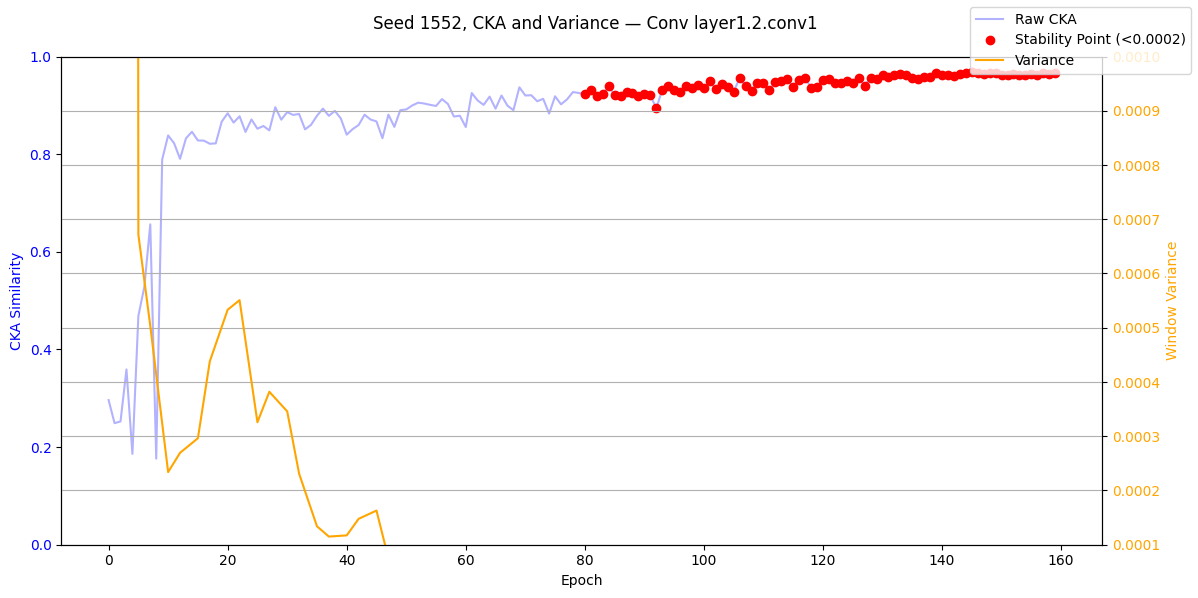

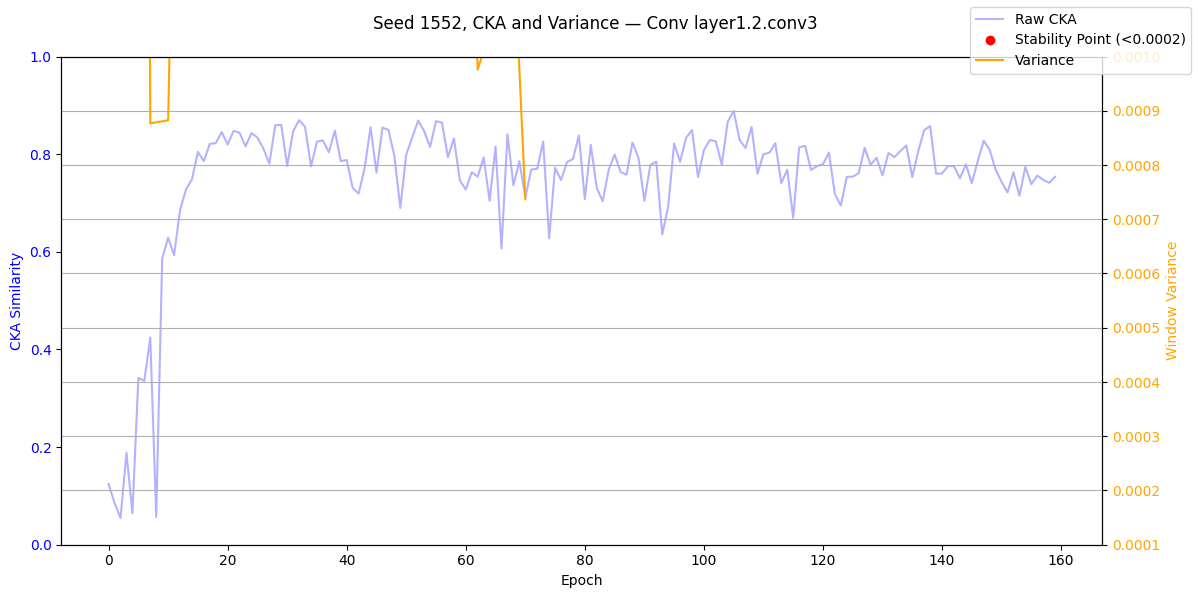

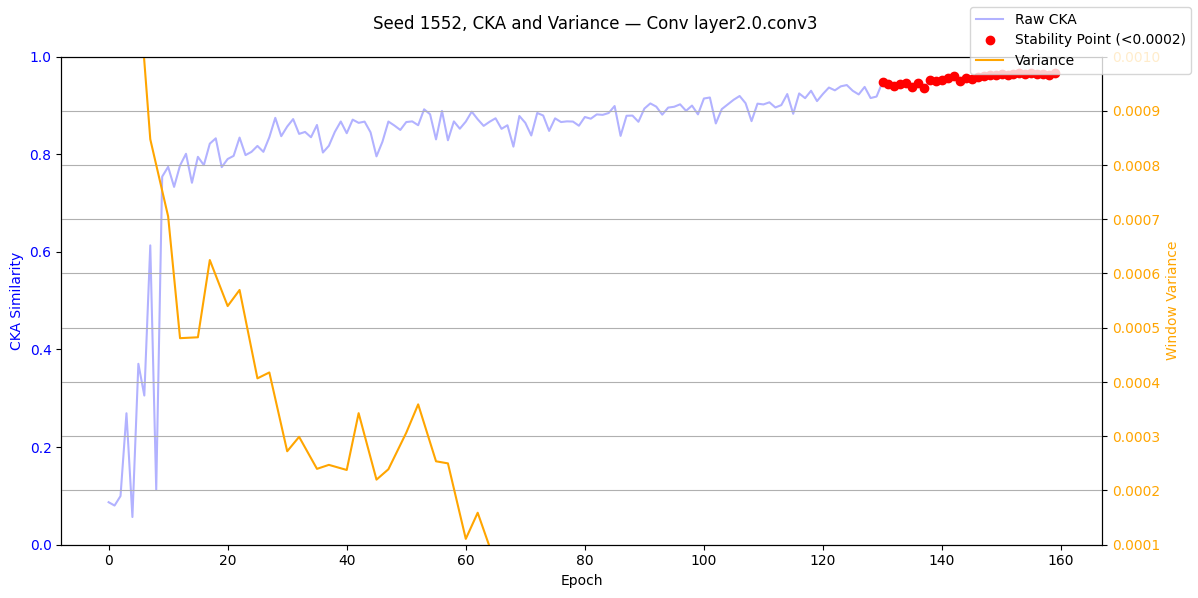

GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER


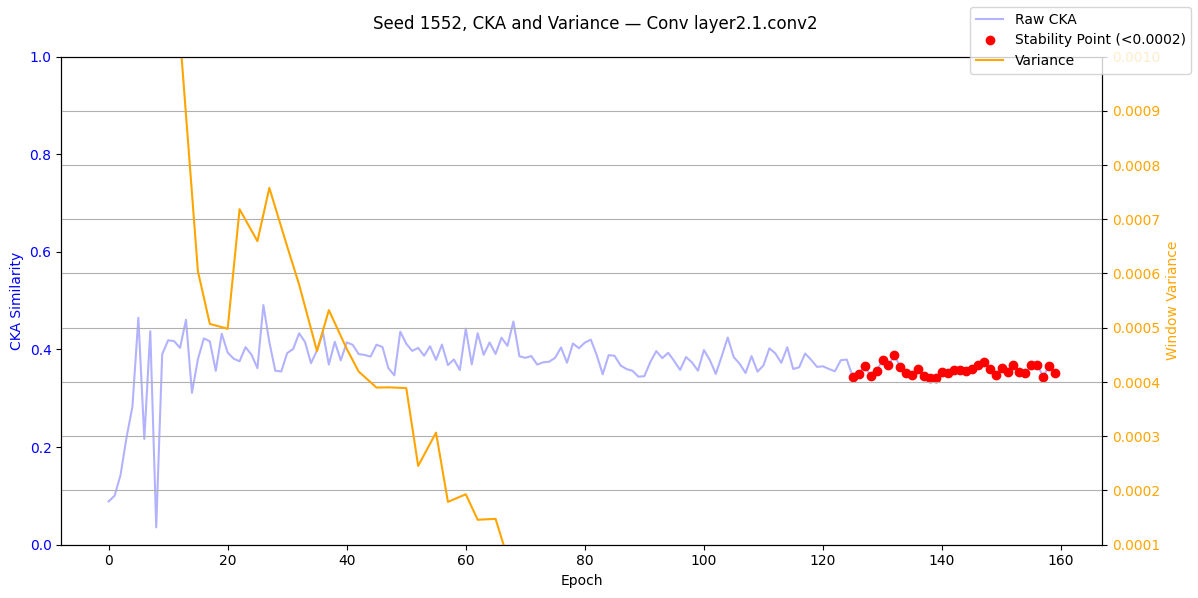

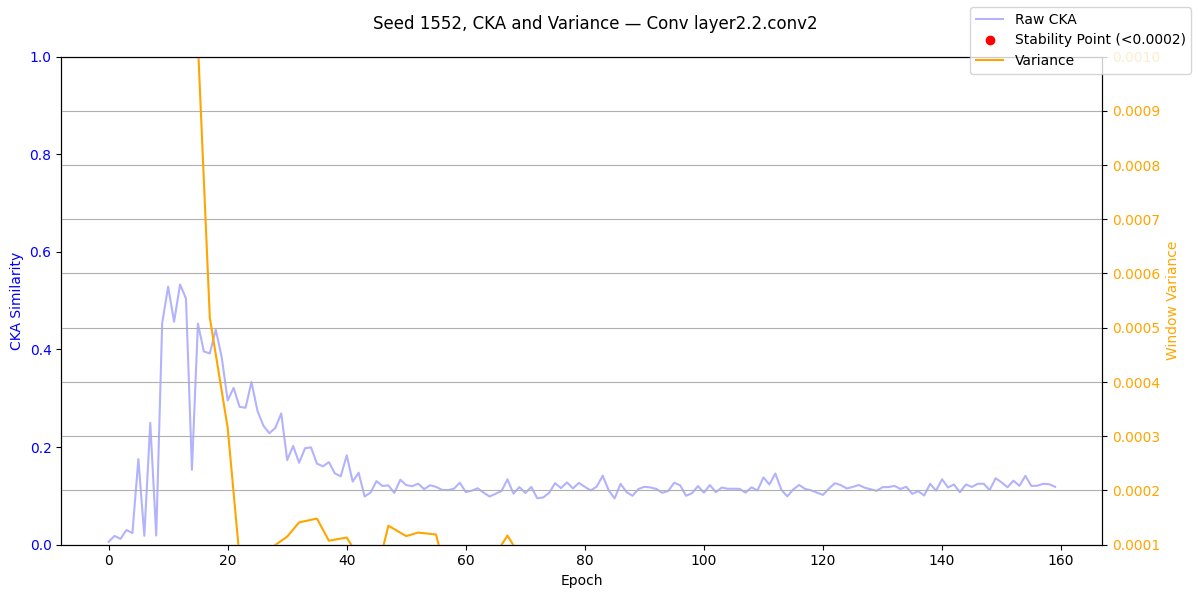

GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER TH

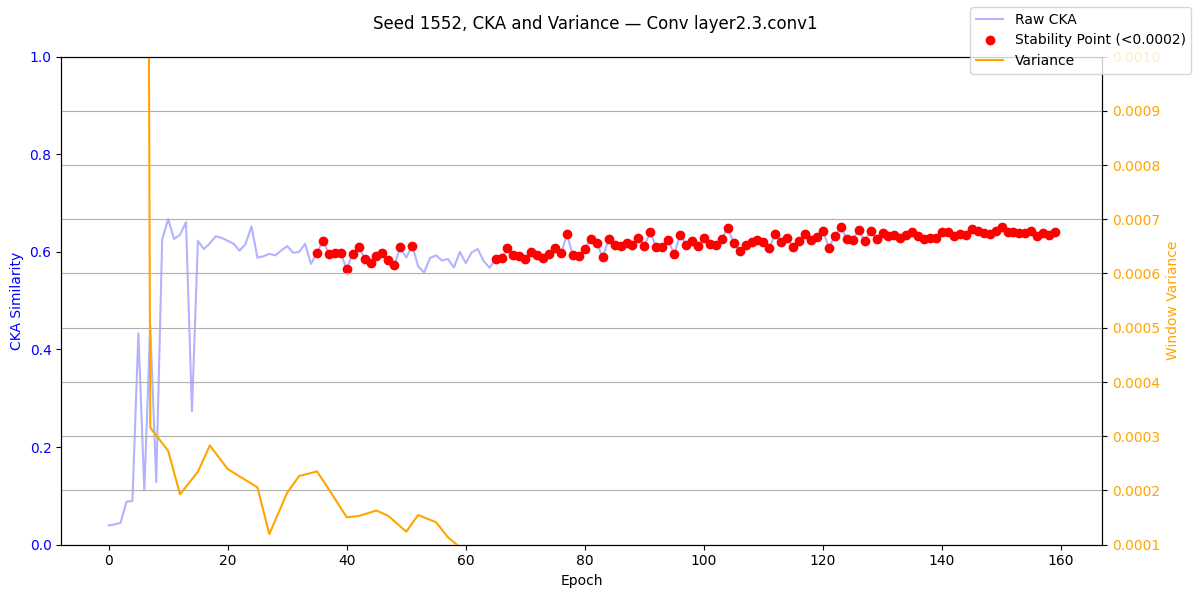

GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER


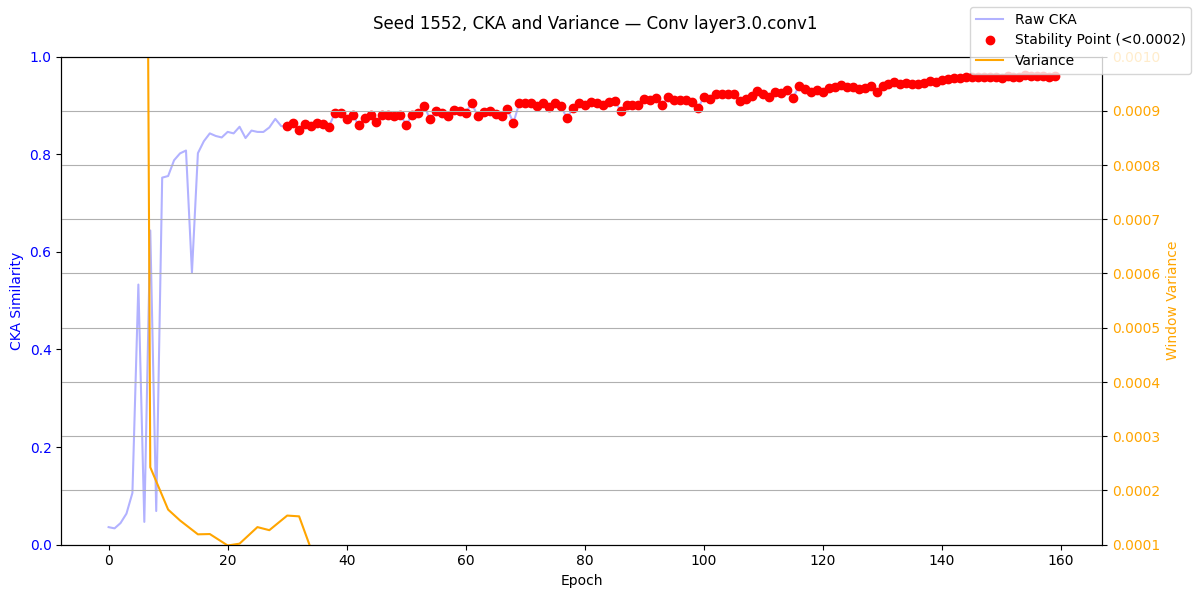

GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER


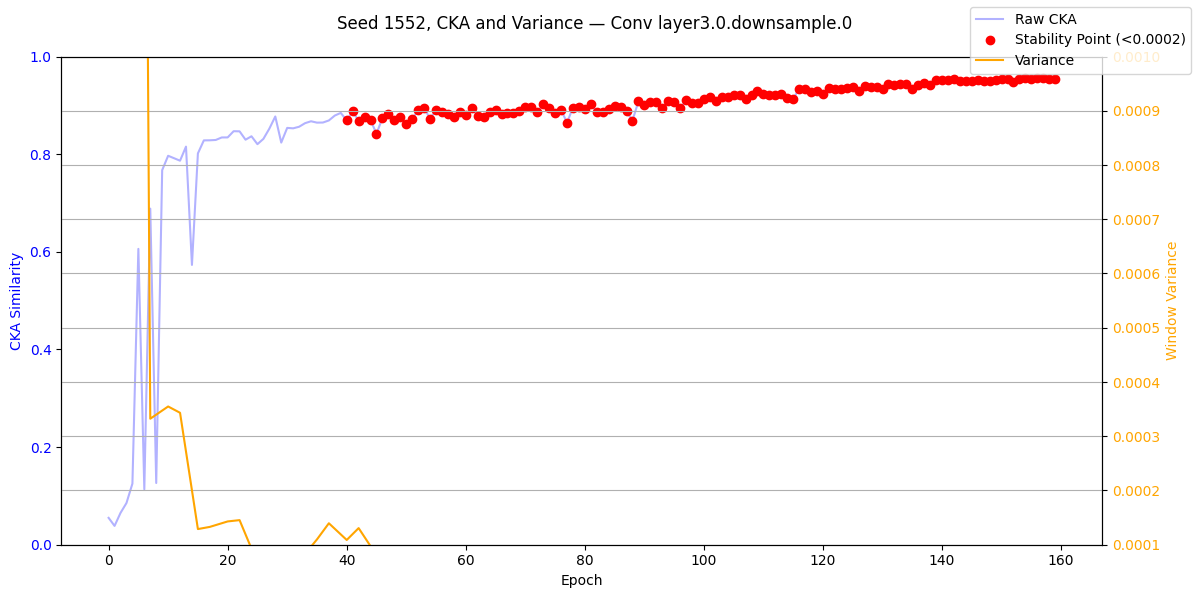

GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER


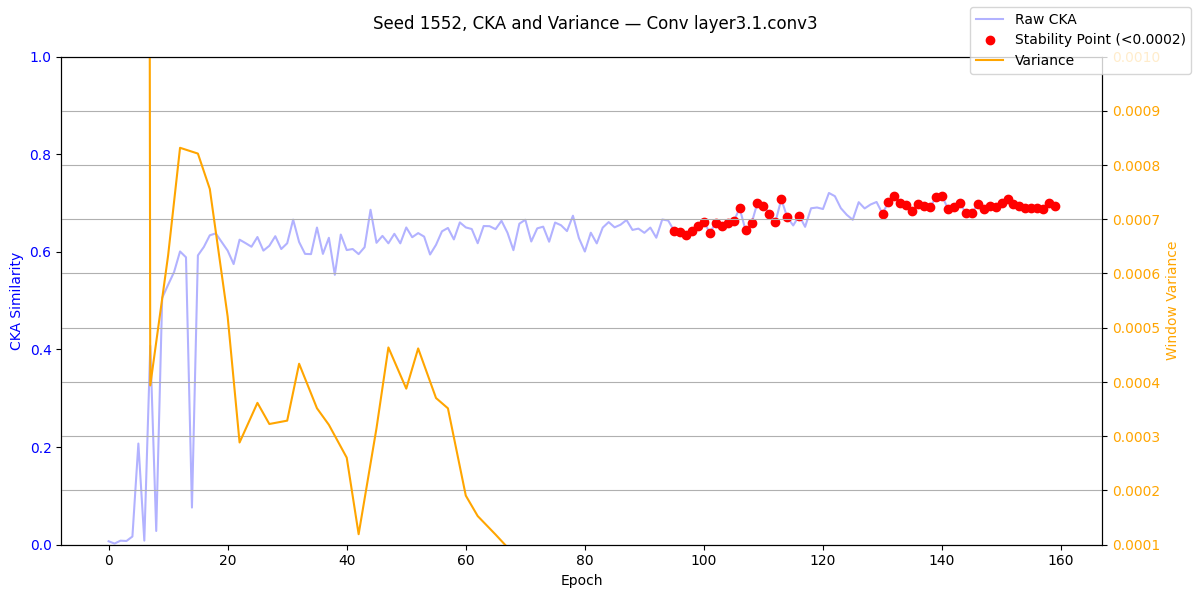

GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER


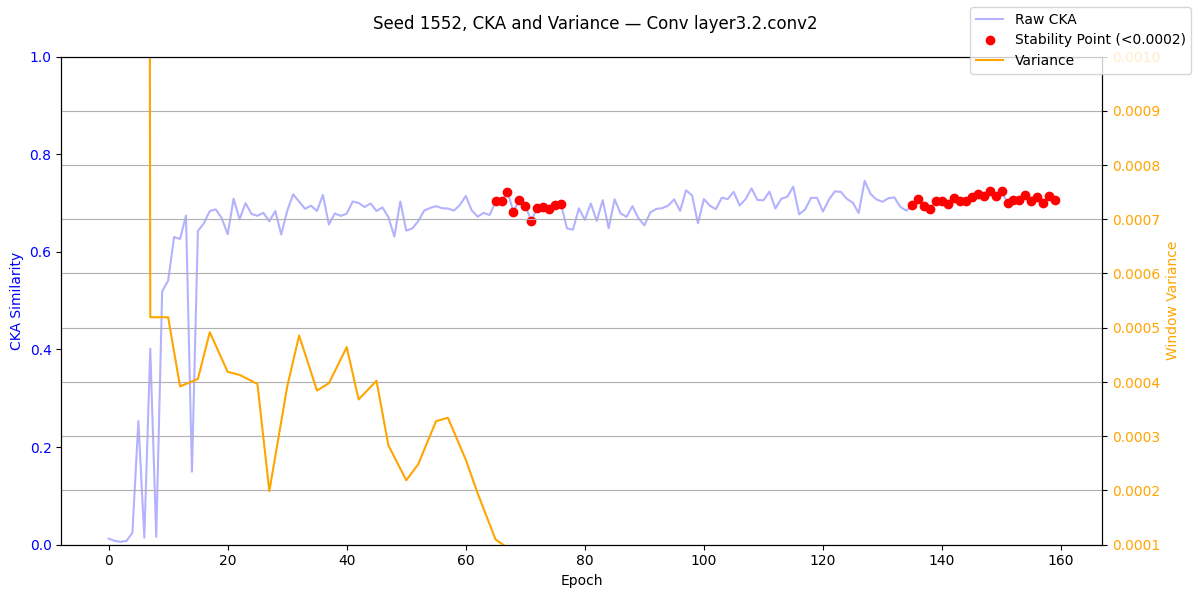

GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER


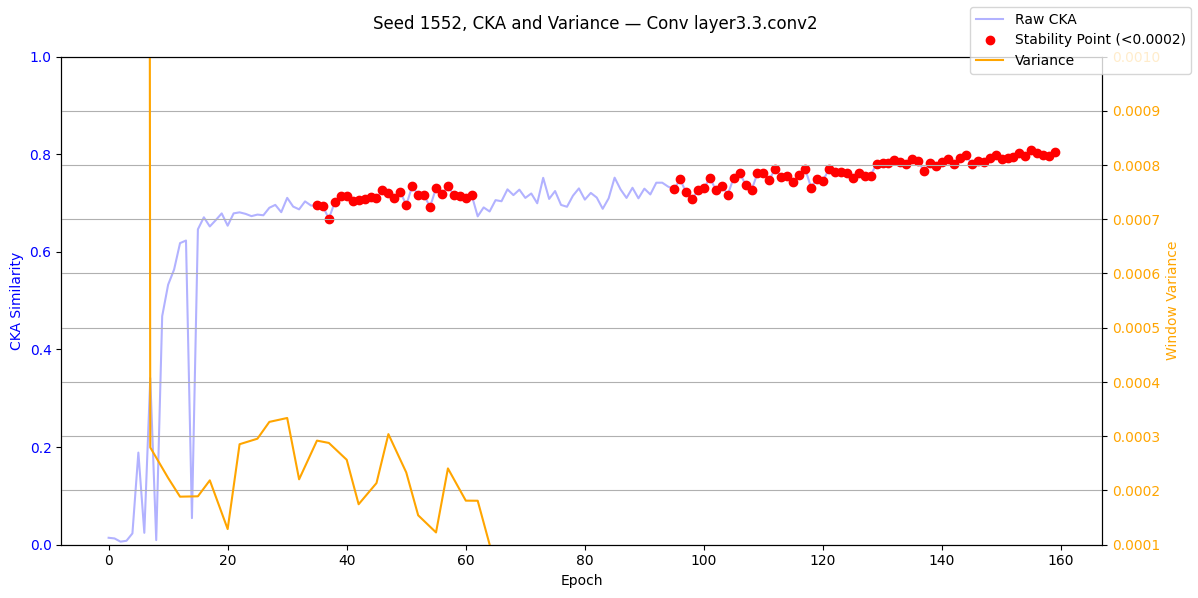

GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER TH

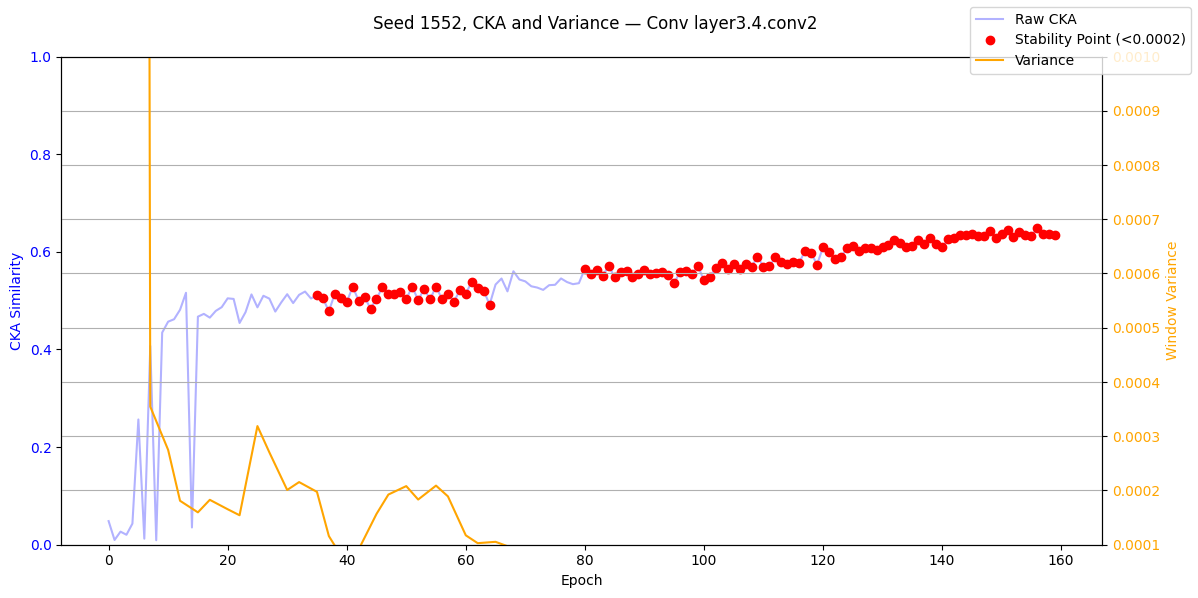

GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER


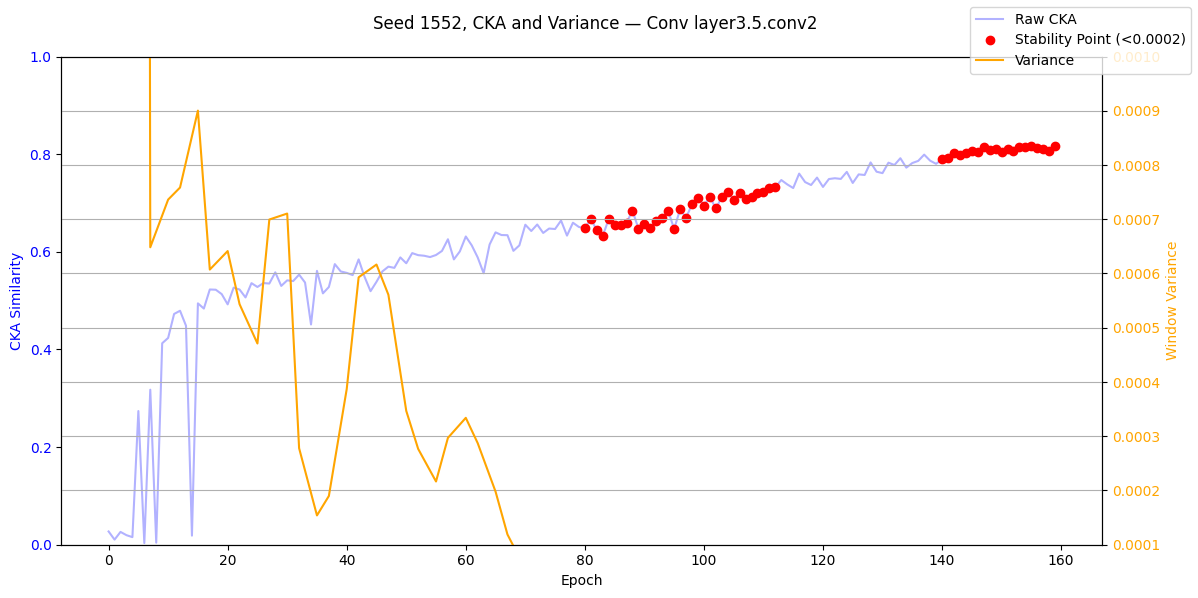

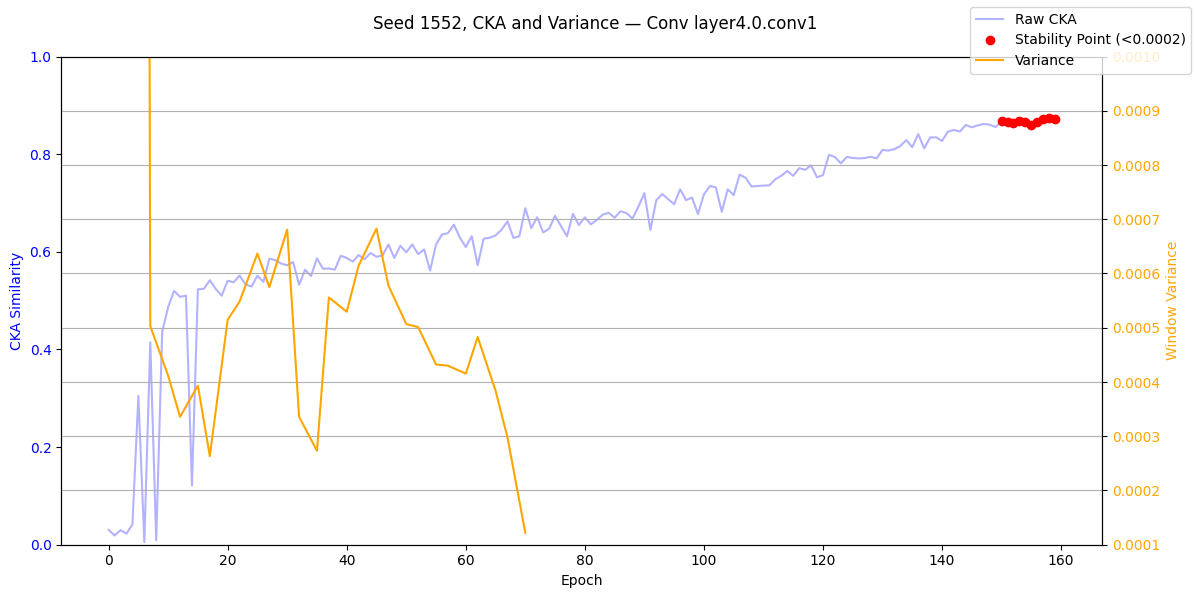

GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 2% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER


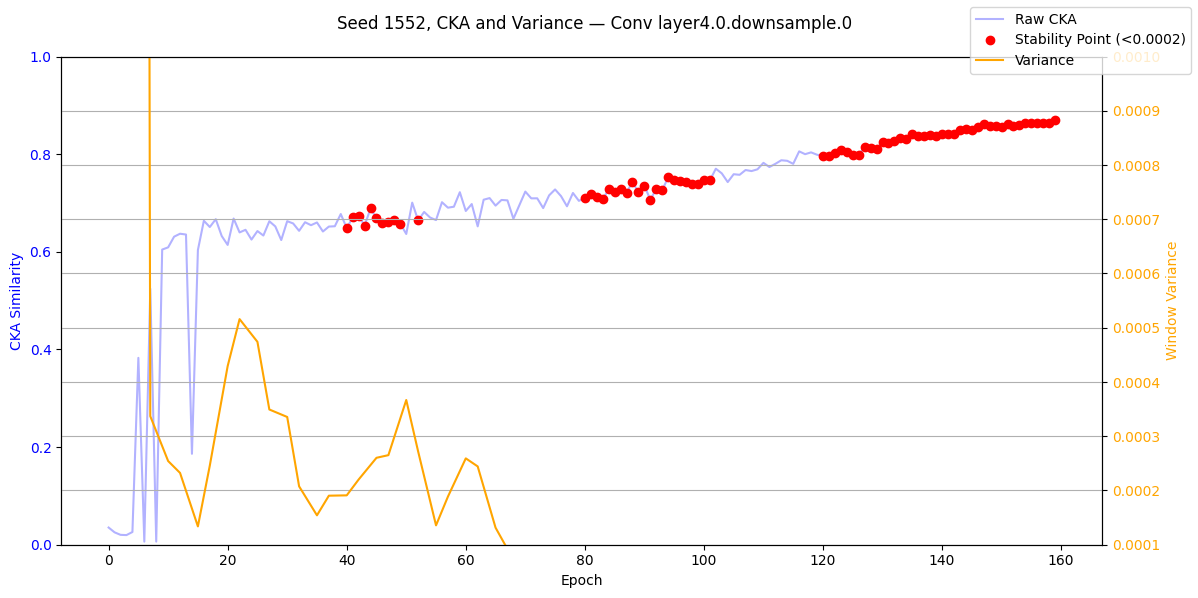

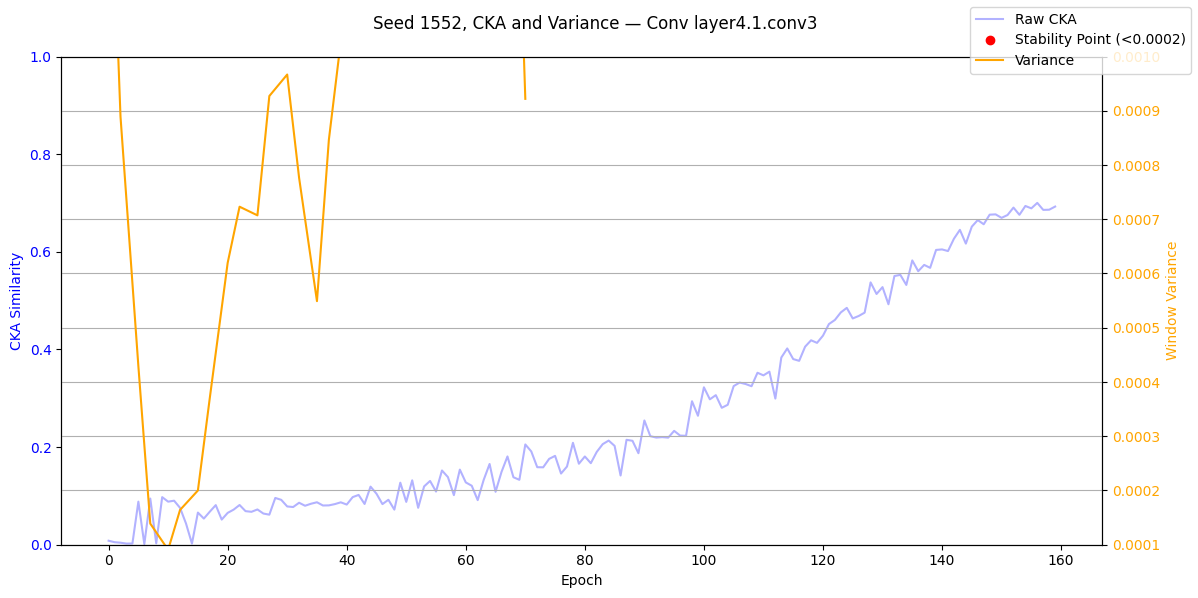

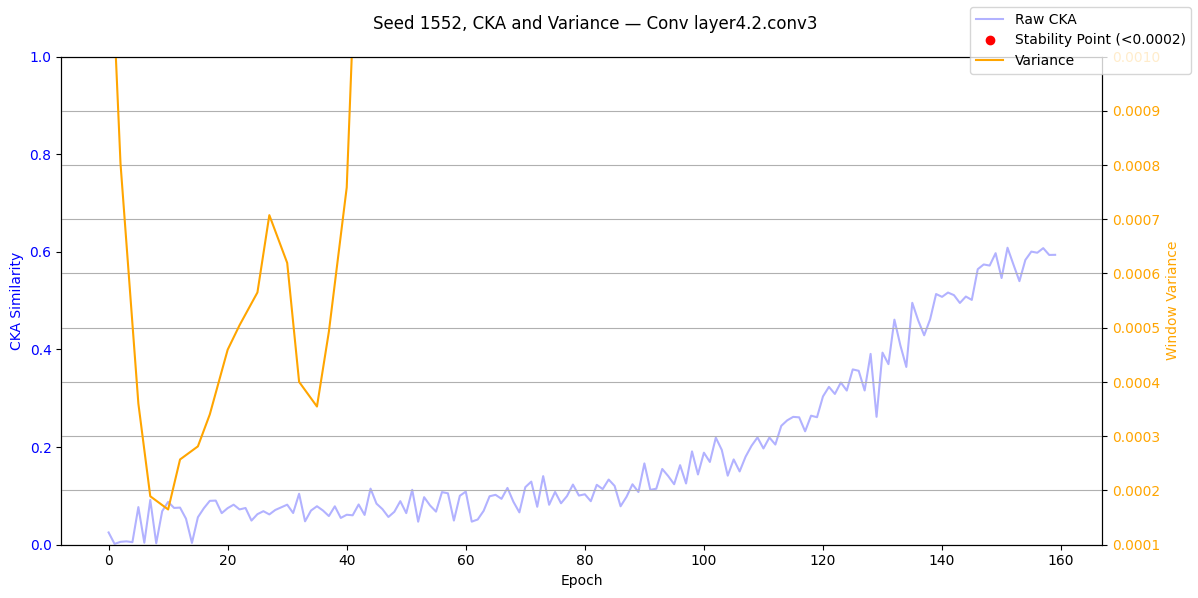

In [217]:
cka_frz_layer_configurations = {}
for seed_directory in seed_directories:
    match = re.search(r"(\d+)$", seed_directory)
    if match:
        seed = int(match.group(1))
    all_epochs_matrix = process_cka_over_time_file_for_plot(seed_directory)
    cka_configuration = get_all_stability_points_for_all_layers(all_epochs_matrix, seed=seed, conv_indices=[i for i in range(number_of_cnn_layers)], layers=layer_names)
    cka_frz_layer_configurations[seed] = cka_configuration

## (5) Look at Number of Frozen vs. Non-Frozen Samples Generated Per Seed

In [218]:
number_of_frozen_samples = 0
number_of_non_frozen_samples = 0
for seed_num, frz_predictions in cka_frz_layer_configurations.items():
    seed_frz_epochs = 0
    seed_no_frz_epochs = 0
    for layer_name in layer_names:
        layer_frz_predictions = frz_predictions[layer_name]
        seed_frz_epochs += sum([pred == 1 for pred in layer_frz_predictions])
        seed_no_frz_epochs += sum([pred == 0 for pred in layer_frz_predictions])
    number_of_frozen_samples += seed_frz_epochs
    number_of_non_frozen_samples += seed_no_frz_epochs
    print(f"Seed {seed_num}, #of Frz Samples: {seed_frz_epochs}, #of NoFrz Samples: {seed_no_frz_epochs}")
print(f"Total number of Frozen Samples: {number_of_frozen_samples}, Total number of Non-Frozen Samples: {number_of_non_frozen_samples}")

Seed 1975, #of Frz Samples: 985, #of NoFrz Samples: 2215
Seed 1552, #of Frz Samples: 1220, #of NoFrz Samples: 1980
Total number of Frozen Samples: 2205, Total number of Non-Frozen Samples: 4195


## (6) Generate Training Dataset with Freeze Predictions

In [219]:
from collections import defaultdict
import copy

context_window_sizes = [30]
flag_for_skipping = True
for context_window_size in context_window_sizes:
    indices_for_sampling = list(range(context_window_size))
    
    output_dir_for_freezing = f"{name_of_location_for_training_data}/context_window_{context_window_size}"
    os.makedirs(output_dir_for_freezing, exist_ok=True)
    os.makedirs(os.path.join(output_dir_for_freezing, "frz"), exist_ok=True)
    os.makedirs(os.path.join(output_dir_for_freezing, "nofrz"), exist_ok=True)
    
    mambafrz_dataset = {}
    
    # Iterate through each seed creating data
    for seed_num, frz_predictions in cka_frz_layer_configurations.items():
        # For each seed, I want a list for each layer with the input weights concatenated across dim=0 or dim=1, depending on predictor type
        # We should create our training data for MambaFRZ and SmartFRZ here:
        # Then after slice through the varying sizes of the sequences
        # before looping layers:
        # Start with SmartFRZ first
        all_weights_cache = {
            epoch: pickle.load(open(
                f"{name_of_experiment}/smartfrz_input_data/seed_{seed_num}_{device}/epoch_{epoch}.pkl", "rb"
            ))
            for epoch in range(num_epochs)
        }
        all_layer_concatenated_input_weights = defaultdict(list)
        all_layer_labels_for_each_epoch = defaultdict(list)
        for layer in layer_names:
            for epoch in range(num_epochs):
                # print(f"Length of weights for Epoch: {epoch} and Layer: {layer_name}",
                #       len(all_weights_cache[epoch][layer_name]))
                weights_for_epoch = all_weights_cache[epoch][layer]
                sampled_input_weights = [weights_for_epoch[i] for i in indices_for_sampling]
                # print(f"Length of weights after sampling: {len(sampled_input_weights)}")
                all_layer_concatenated_input_weights[layer].extend(sampled_input_weights)
                all_layer_labels_for_each_epoch[layer].append(frz_predictions[layer][epoch])
    
        for layer in layer_names:
            all_layer_concatenated_input_weights[layer] = torch.stack([entry[0] for entry in all_layer_concatenated_input_weights[layer]], dim=0)
            print(all_layer_concatenated_input_weights[layer].shape)
        mambafrz_dataset[seed_num] = (all_layer_concatenated_input_weights, all_layer_labels_for_each_epoch)

torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])
torch.Size([4800, 1024])


In [220]:
with open(f"{name_of_location_for_training_data}/context_window_30/mambafrz_testing_dataset.pkl", "wb") as f:
    pickle.dump(mambafrz_dataset, f)